# _Maquinas Delirantes - Projeto 1_
# LuizVini


### Importando Bibliotecas


In [1]:
import csv
import math
from heapq import heappop, heappush
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"


# ============================================================
# 1) Descobrindo onde estamos
# ============================================================
# Quero que este notebook rode tanto na raiz do projeto
# quanto dentro de uma pasta de notebooks, caso eu o mova.
if (Path(".") / "Dataset_Projeto1").exists():
    BASE = Path(".").resolve()
elif (Path("..") / "Dataset_Projeto1").exists():
    BASE = Path("..").resolve()
else:
    raise RuntimeError("Nao encontrei a pasta Dataset_Projeto1.")

PASTA_DATASET = BASE / "Dataset_Projeto1"
PASTA_EUCALIPTO = PASTA_DATASET / "_Eucalipto_Escolhidos1"
PASTA_PINHEIRO = PASTA_DATASET / "_Pinheiro_Escolhidos1"

PASTA_SAIDA = BASE / "Resultados_LuizVini_Projeto1"
PASTA_FIGURAS = PASTA_SAIDA / "figuras"
PASTA_ANOTADAS = PASTA_SAIDA / "anotadas"
PASTA_DEBUG = PASTA_SAIDA / "debug"

for pasta in [PASTA_SAIDA, PASTA_FIGURAS, PASTA_ANOTADAS, PASTA_DEBUG]:
    pasta.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2) Listando as imagens
# ============================================================
CAMINHOS_EUCALIPTO = sorted(PASTA_EUCALIPTO.glob("*.jpg"))
CAMINHOS_PINHEIRO = sorted(PASTA_PINHEIRO.glob("*.jpg"))
CAMINHOS_IMAGENS = CAMINHOS_EUCALIPTO + CAMINHOS_PINHEIRO

print("BASE:", BASE)
print("Qtd eucaliptos:", len(CAMINHOS_EUCALIPTO))
print("Qtd pinheiros:", len(CAMINHOS_PINHEIRO))
print("Qtd total:", len(CAMINHOS_IMAGENS))


BASE: C:\Users\dado7\OneDrive\Documentos\INSPER\Insper 2026.1\MachinesVision\VisionsProjeto1\machine-vision
Qtd eucaliptos: 5
Qtd pinheiros: 3
Qtd total: 8


_______________________
## O desafio

### Precisamos inspecionar morfologicamente mudas de **eucalipto** e **pinheiro**.

O professor pediu, essencialmente, quatro atributos:
- comprimento total da planta
- diametro de coleto
- area foliar
- numero de folhas

A boa noticia e que o setup do dataset ajuda bastante: temos **fundo azul**, **tubete preto** e **cilindro branco**. Entao a estrategia natural foi:

1. separar o fundo azul
2. isolar planta, tubete e cilindro
3. descobrir onde termina o tubete e onde fica o coleto
4. medir os atributos em pixels
5. gerar imagens anotadas e uma tabela final

Tudo aqui foi feito com **visao classica**, no espirito das APSs 2 e 3: mascara, morfologia, componentes conectados, contorno visual e algumas medidas geometricas bem explicadas.


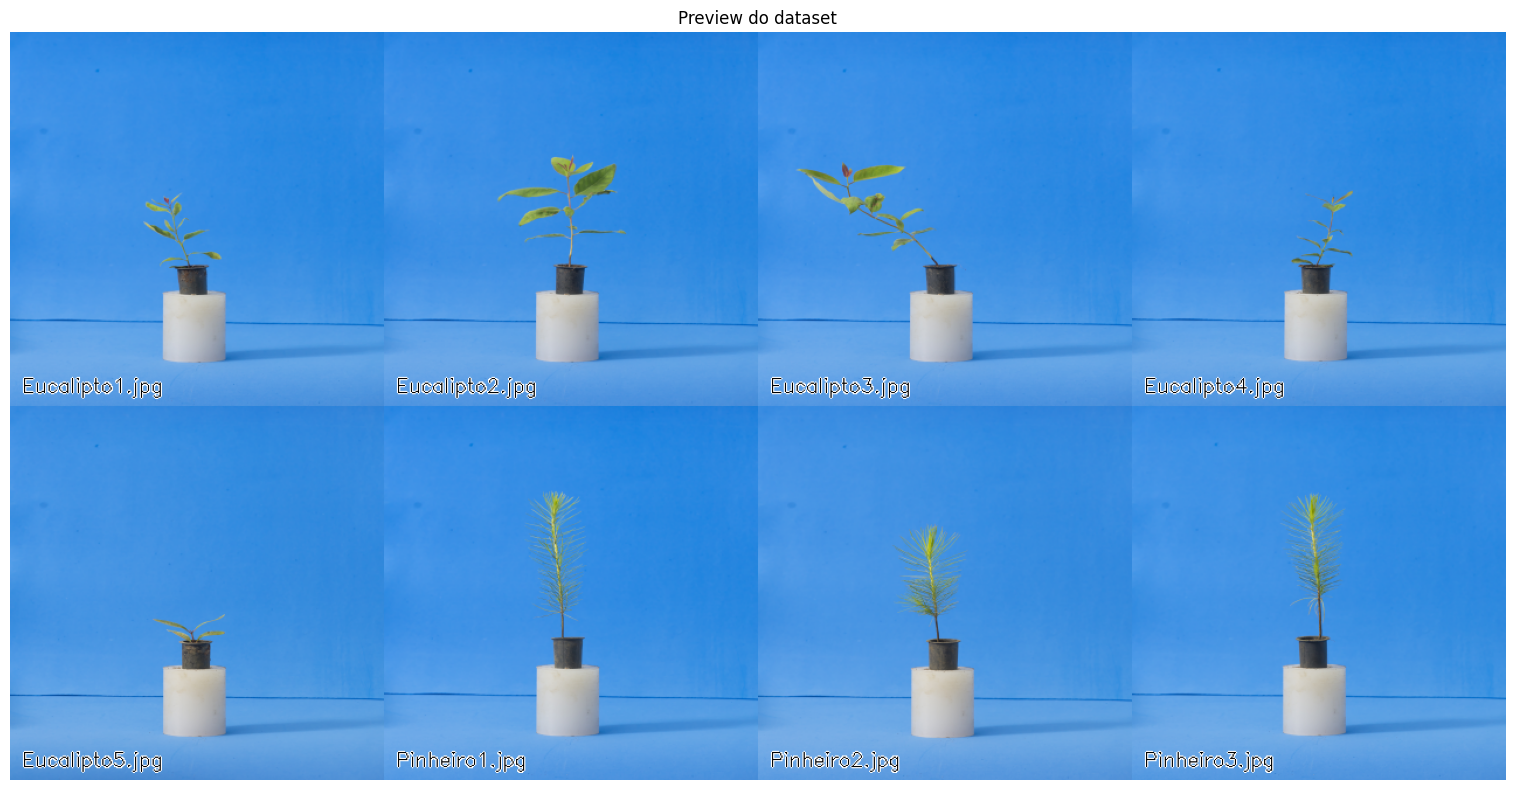

In [2]:
# ============================================================
# Funcoes basicas de leitura e visualizacao
# ============================================================
def LerImagemBGR(caminho):
    img = cv2.imread(str(caminho), cv2.IMREAD_COLOR)

    if img is None:
        raise RuntimeError("Nao consegui abrir a imagem: " + str(caminho))

    return img


def BGR2RGB(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def InfereEspecie(nome_arquivo):
    nome = nome_arquivo.lower()

    if "eucalipto" in nome:
        return "eucalyptus"

    if "pinheiro" in nome:
        return "pine"

    return "unknown"


def SalvaImagem(caminho, img):
    caminho.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(caminho), img)


def MontaMosaicoRotulado(caminhos, tile=320, colunas=4):
    imagens = []

    for caminho in caminhos:
        img = LerImagemBGR(caminho)
        img = cv2.resize(img, (tile, tile), interpolation=cv2.INTER_AREA)

        cv2.putText(img, caminho.name, (10, tile - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
        cv2.putText(img, caminho.name, (10, tile - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1)
        imagens.append(img)

    linhas = math.ceil(len(imagens) / colunas)
    branco = np.zeros_like(imagens[0])

    grade = []
    idx = 0

    for _ in range(linhas):
        linha = []

        for _ in range(colunas):
            if idx < len(imagens):
                linha.append(imagens[idx])
            else:
                linha.append(branco)

            idx += 1

        grade.append(np.hstack(linha))

    return np.vstack(grade)


mosaico = MontaMosaicoRotulado(CAMINHOS_IMAGENS, tile=320, colunas=4)
SalvaImagem(PASTA_FIGURAS / "01_preview_dataset.png", mosaico)

plt.figure(figsize=(16, 8))
plt.imshow(BGR2RGB(mosaico))
plt.title("Preview do dataset")
plt.axis("off")
plt.tight_layout()
plt.show()


_______________________
## Etapa 1

### Segmentando a cena

A separacao principal e por cor:
- o **fundo** e azul
- o **tubete** e preto
- o **cilindro de apoio** e branco
- a **planta** fica no que sobra, com reforco por faixa de cor verde

Como sempre, a mascara bruta nunca vem linda. Entao aplicamos uma limpeza morfologica e removemos componentes muito pequenos para nao sermos enganados por ruido.


In [3]:
# ============================================================
# Funcoes de apoio para mascara e morfologia
# ============================================================
def Morfologia(mask, open_k=3, close_k=5):
    out = (mask.astype(np.uint8) * 255).copy()

    if open_k > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_k, open_k))
        out = cv2.morphologyEx(out, cv2.MORPH_OPEN, kernel)

    if close_k > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_k, close_k))
        out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, kernel)

    return out > 0


def LimpaComponentesPequenos(mask, area_min=200):
    rotulos, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    saida = np.zeros_like(mask, dtype=bool)

    for idx in range(1, rotulos):
        area = stats[idx, cv2.CC_STAT_AREA]

        if area >= area_min:
            saida |= labels == idx

    return saida


def MaiorComponente(mask):
    rotulos, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)

    melhor_idx = -1
    melhor_area = -1

    for idx in range(1, rotulos):
        area = stats[idx, cv2.CC_STAT_AREA]

        if area > melhor_area:
            melhor_area = area
            melhor_idx = idx

    if melhor_idx < 0:
        return np.zeros_like(mask, dtype=bool)

    return labels == melhor_idx


def BBoxMascara(mask):
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return (0, 0, 0, 0)

    return (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max()))


def MascaraNaROI(mask, y_min, x_center, x_half_window):
    h, w = mask.shape

    x0 = max(0, x_center - x_half_window)
    x1 = min(w, x_center + x_half_window)

    roi = np.zeros_like(mask, dtype=bool)
    roi[y_min:, x0:x1] = True

    return MaiorComponente(mask & roi)


def SegmentosDaLinha(row_bool):
    xs = np.where(row_bool)[0]

    if len(xs) == 0:
        return []

    segmentos = []
    ini = xs[0]
    prev = xs[0]

    for x in xs[1:]:
        if x == prev + 1:
            prev = x
            continue

        segmentos.append((int(ini), int(prev)))
        ini = x
        prev = x

    segmentos.append((int(ini), int(prev)))
    return segmentos


def AchaPontoColeto(mask_planta, y_topo_tubete, x_centro_tubete, busca_acima=30, busca_abaixo=90, meia_janela=170):
    h, w = mask_planta.shape

    y0 = max(0, y_topo_tubete - busca_acima)
    y1 = min(h, y_topo_tubete + busca_abaixo)
    x0 = max(0, x_centro_tubete - meia_janela)
    x1 = min(w, x_centro_tubete + meia_janela)

    melhor = None
    melhor_score = float("inf")

    for y in range(y0, y1):
        for a, b in SegmentosDaLinha(mask_planta[y, x0:x1]):
            xa = a + x0
            xb = b + x0
            largura = xb - xa + 1
            x_centro = (xa + xb) / 2.0

            score = (
                2.0 * abs(y - y_topo_tubete) +
                0.9 * abs(x_centro - x_centro_tubete) +
                1.3 * largura
            )

            if largura < 2 or largura > 50:
                score += 50

            if score < melhor_score:
                melhor_score = score
                melhor = (int(round(x_centro)), int(y))

    if melhor is None:
        return (x_centro_tubete, y_topo_tubete)

    return melhor


def DiametroReferenciaBranca(mask_branca):
    if not np.any(mask_branca):
        return None

    rotulos, labels, stats, _ = cv2.connectedComponentsWithStats(mask_branca.astype(np.uint8), connectivity=8)

    melhor_idx = -1
    melhor_score = -1.0

    for idx in range(1, rotulos):
        area = stats[idx, cv2.CC_STAT_AREA]
        largura = stats[idx, cv2.CC_STAT_WIDTH]
        altura = stats[idx, cv2.CC_STAT_HEIGHT]

        if area < 1000:
            continue

        score = area * (min(largura, altura) / (max(largura, altura) + 1e-6))

        if score > melhor_score:
            melhor_score = score
            melhor_idx = idx

    if melhor_idx < 0:
        return None

    ys, xs = np.where(labels == melhor_idx)

    if len(xs) < 10:
        return None

    diam_x = xs.max() - xs.min() + 1
    diam_y = ys.max() - ys.min() + 1

    return float((diam_x + diam_y) / 2.0)


def SobrepoeMascara(img_bgr, mask, cor_bgr, alpha=0.45):
    out = img_bgr.copy()
    overlay = np.zeros_like(out)
    overlay[mask] = cor_bgr
    cv2.addWeighted(overlay, alpha, out, 1 - alpha, 0, out)
    return out


def DesenhaContornoMascara(img_bgr, mask, cor_bgr, espessura=2):
    out = img_bgr.copy()
    contornos, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(out, contornos, -1, cor_bgr, espessura)
    return out


def FaixaTopoTubete(mask_tubete, y_topo_tubete):
    y0 = max(0, y_topo_tubete - 1)
    y1 = min(mask_tubete.shape[0], y_topo_tubete + 3)
    xs = np.where(np.any(mask_tubete[y0:y1, :], axis=0))[0]

    if len(xs) == 0:
        return None

    return (int(xs.min()), int(xs.max()), int(y_topo_tubete))


def SegmentaCena(img_bgr):
    h, w = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]

    # ========================================================
    # 1) Fundo azul
    # ========================================================
    mascara_fundo = (
        (H >= 85) & (H <= 130) &
        (S >= 70) &
        (V >= 40)
    )

    mascara_frente = ~mascara_fundo
    mascara_frente = Morfologia(mascara_frente, open_k=3, close_k=5)
    mascara_frente = LimpaComponentesPequenos(mascara_frente, area_min=200)

    # ========================================================
    # 2) Tubete preto e cilindro branco
    # ========================================================
    mascara_preta = (V <= 75) & (S <= 120) & mascara_frente
    mascara_preta = Morfologia(mascara_preta, open_k=3, close_k=5)

    mascara_branca = (V >= 180) & (S <= 70) & mascara_frente
    mascara_branca = Morfologia(mascara_branca, open_k=3, close_k=5)

    mascara_tubete = MascaraNaROI(
        mascara_preta,
        y_min=int(0.45 * h),
        x_center=w // 2,
        x_half_window=int(0.26 * w),
    )

    mascara_cilindro = MascaraNaROI(
        mascara_branca,
        y_min=int(0.50 * h),
        x_center=w // 2,
        x_half_window=int(0.30 * w),
    )

    # ========================================================
    # 3) Planta
    # ========================================================
    mascara_cor_planta = (
        (H >= 25) & (H <= 95) &
        (S >= 25) &
        (V >= 30)
    )

    mascara_planta = mascara_frente & (~mascara_tubete) & (~mascara_cilindro)
    mascara_planta &= (mascara_cor_planta | (S >= 35))
    mascara_planta = Morfologia(mascara_planta, open_k=3, close_k=5)
    mascara_planta = LimpaComponentesPequenos(mascara_planta, area_min=200)

    # ========================================================
    # 4) Geometria de referencia
    # ========================================================
    if np.any(mascara_tubete):
        x0, y0, x1, y1 = BBoxMascara(mascara_tubete)
        y_topo_tubete = y0
        centro_tubete = ((x0 + x1) // 2, (y0 + y1) // 2)
    else:
        x0, y0, x1, y1 = (0, 0, 0, 0)
        y_topo_tubete = int(0.62 * h)
        centro_tubete = (w // 2, y_topo_tubete)

    mascara_planta_acima_tubete = mascara_planta.copy()
    mascara_planta_acima_tubete[y_topo_tubete + 4 :, :] = False
    mascara_planta_acima_tubete = LimpaComponentesPequenos(mascara_planta_acima_tubete, area_min=200)

    ponto_coleto = AchaPontoColeto(mascara_planta, y_topo_tubete, centro_tubete[0])
    diametro_referencia_px = DiametroReferenciaBranca(mascara_cilindro)

    return {
        "mascara_fundo": mascara_fundo,
        "mascara_frente": mascara_frente,
        "mascara_tubete": mascara_tubete,
        "mascara_cilindro": mascara_cilindro,
        "mascara_planta": mascara_planta,
        "mascara_planta_acima_tubete": mascara_planta_acima_tubete,
        "y_topo_tubete": y_topo_tubete,
        "bbox_tubete": (x0, y0, x1, y1),
        "centro_tubete": centro_tubete,
        "ponto_coleto": ponto_coleto,
        "diametro_referencia_px": diametro_referencia_px,
    }


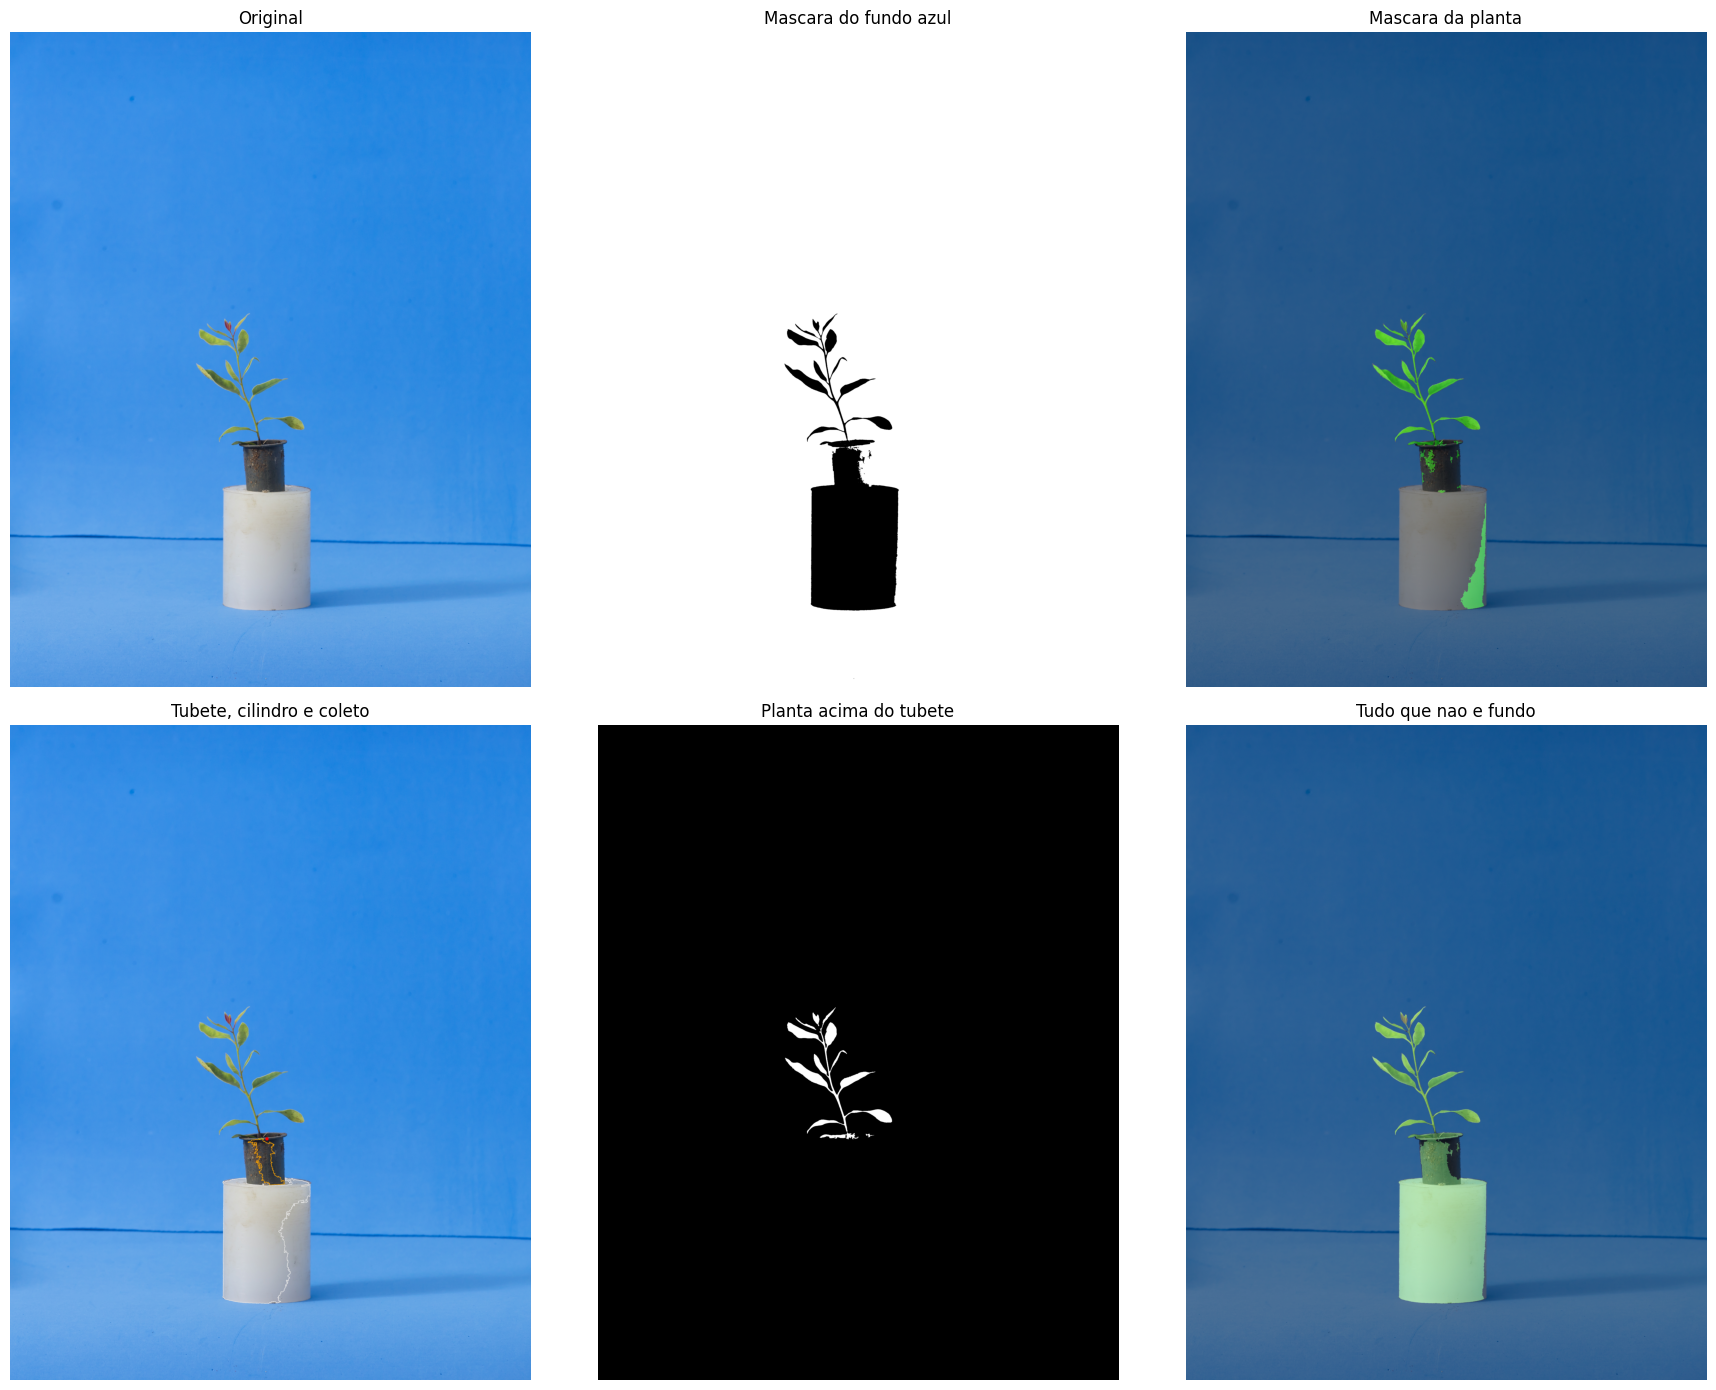

In [4]:
# ============================================================
# Exemplo de segmentacao - eucalipto
# ============================================================
caminho_exemplo = CAMINHOS_EUCALIPTO[0]
img = LerImagemBGR(caminho_exemplo)
seg = SegmentaCena(img)

vis_tubete = img.copy()
vis_tubete = DesenhaContornoMascara(vis_tubete, seg["mascara_tubete"], (0, 165, 255), espessura=2)
vis_tubete = DesenhaContornoMascara(vis_tubete, seg["mascara_cilindro"], (230, 230, 230), espessura=2)

faixa = FaixaTopoTubete(seg["mascara_tubete"], seg["y_topo_tubete"])

if faixa is not None:
    x_ini, x_fim, y_rim = faixa
    cv2.line(vis_tubete, (x_ini, y_rim), (x_fim, y_rim), (0, 255, 255), 2)

cv2.circle(vis_tubete, seg["ponto_coleto"], 10, (0, 0, 255), -1)

fig, axs = plt.subplots(2, 3, figsize=(18, 14))

axs[0, 0].imshow(BGR2RGB(img))
axs[0, 0].set_title("Original")
axs[0, 0].axis("off")

axs[0, 1].imshow(seg["mascara_fundo"], cmap="gray")
axs[0, 1].set_title("Mascara do fundo azul")
axs[0, 1].axis("off")

axs[0, 2].imshow(BGR2RGB(SobrepoeMascara(img, seg["mascara_planta"], (0, 255, 0), alpha=0.40)))
axs[0, 2].set_title("Mascara da planta")
axs[0, 2].axis("off")

axs[1, 0].imshow(BGR2RGB(vis_tubete))
axs[1, 0].set_title("Tubete, cilindro e coleto")
axs[1, 0].axis("off")

axs[1, 1].imshow(seg["mascara_planta_acima_tubete"], cmap="gray")
axs[1, 1].set_title("Planta acima do tubete")
axs[1, 1].axis("off")

axs[1, 2].imshow(BGR2RGB(SobrepoeMascara(img, seg["mascara_frente"], (120, 255, 120), alpha=0.35)))
axs[1, 2].set_title("Tudo que nao e fundo")
axs[1, 2].axis("off")

plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "02_segmentacao_eucalipto.png", dpi=160)
plt.show()


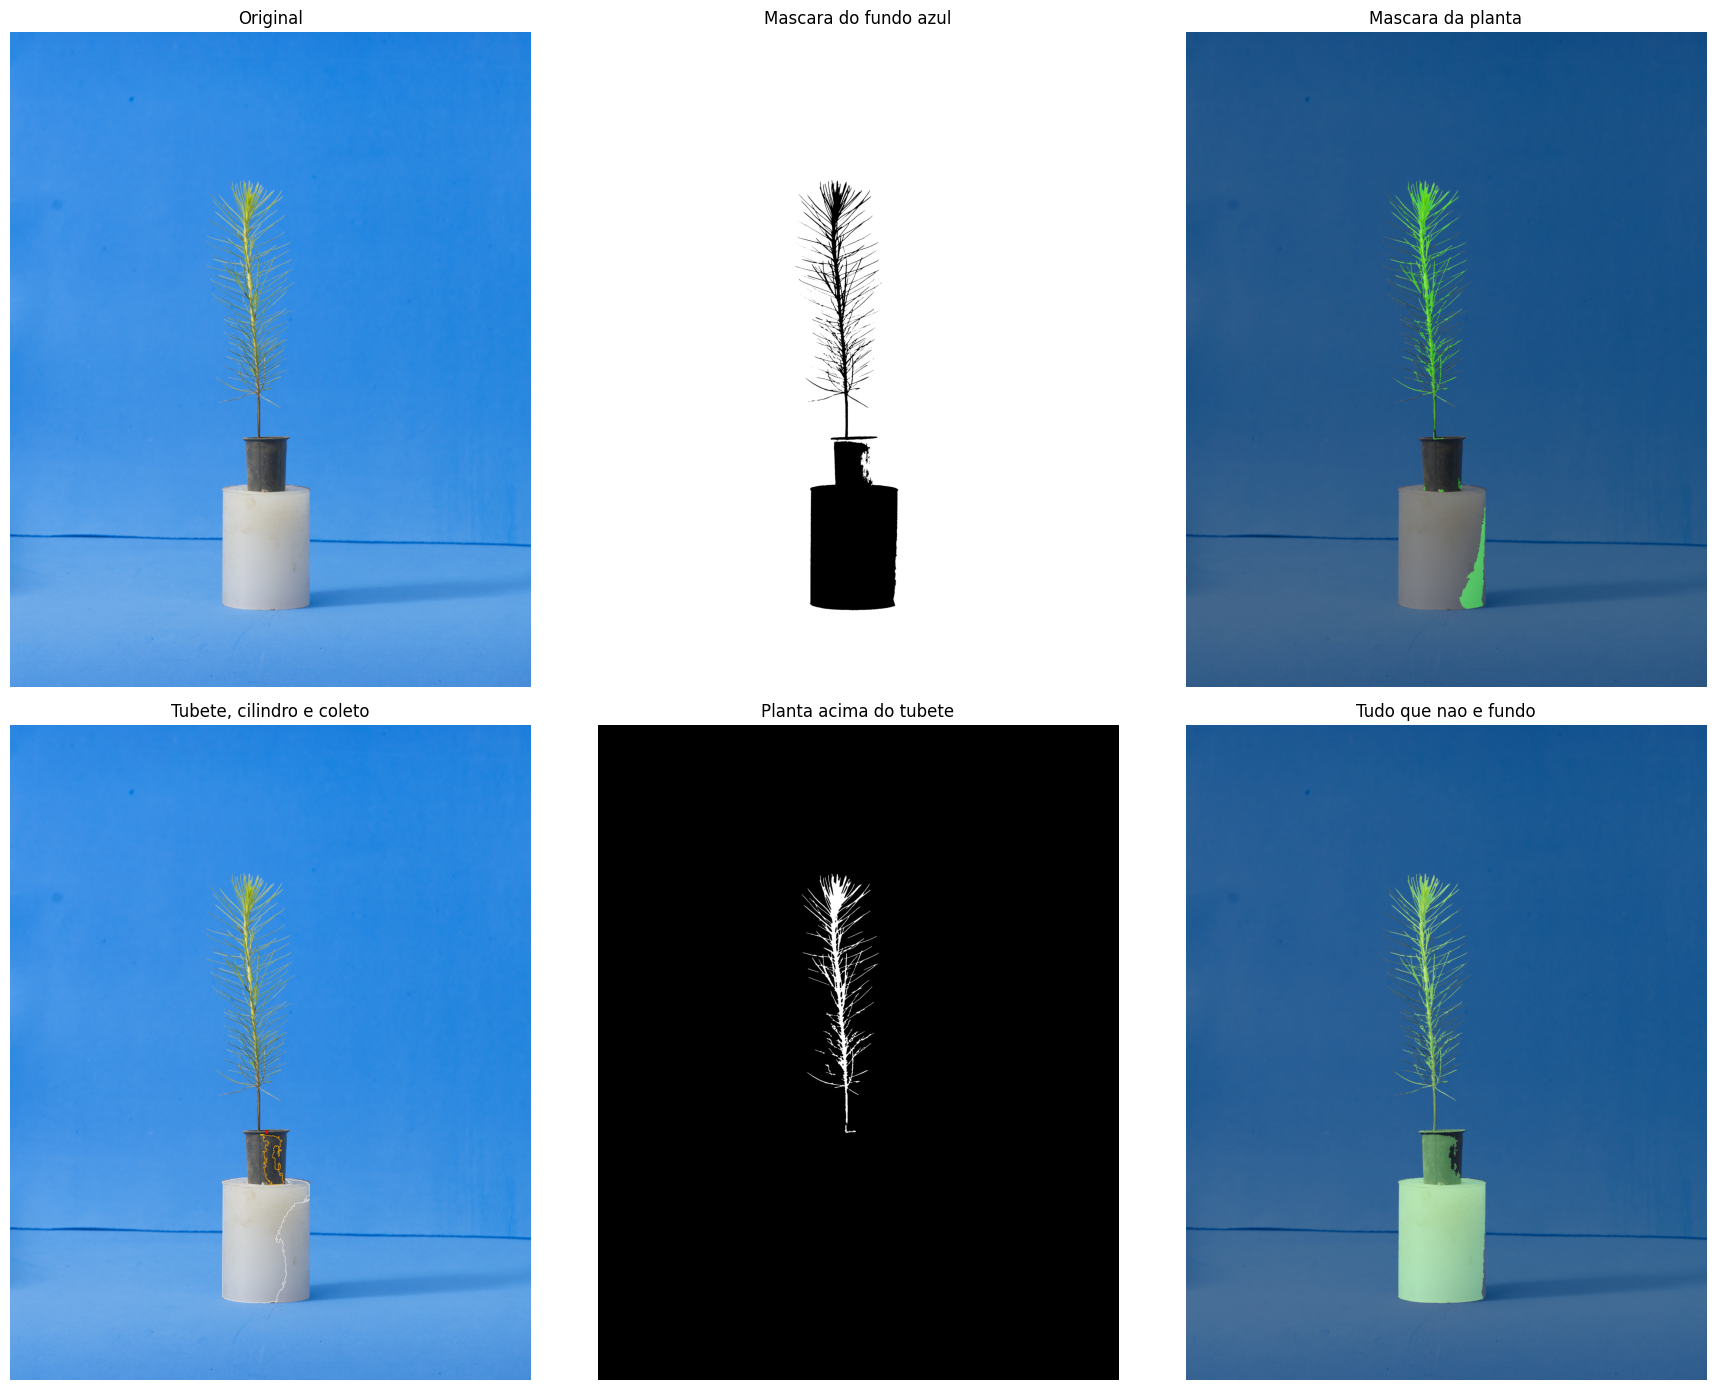

In [5]:
# ============================================================
# Exemplo de segmentacao - pinheiro
# ============================================================
caminho_exemplo = CAMINHOS_PINHEIRO[0]
img = LerImagemBGR(caminho_exemplo)
seg = SegmentaCena(img)

vis_tubete = img.copy()
vis_tubete = DesenhaContornoMascara(vis_tubete, seg["mascara_tubete"], (0, 165, 255), espessura=2)
vis_tubete = DesenhaContornoMascara(vis_tubete, seg["mascara_cilindro"], (230, 230, 230), espessura=2)

faixa = FaixaTopoTubete(seg["mascara_tubete"], seg["y_topo_tubete"])

if faixa is not None:
    x_ini, x_fim, y_rim = faixa
    cv2.line(vis_tubete, (x_ini, y_rim), (x_fim, y_rim), (0, 255, 255), 2)

cv2.circle(vis_tubete, seg["ponto_coleto"], 10, (0, 0, 255), -1)

fig, axs = plt.subplots(2, 3, figsize=(18, 14))

axs[0, 0].imshow(BGR2RGB(img))
axs[0, 0].set_title("Original")
axs[0, 0].axis("off")

axs[0, 1].imshow(seg["mascara_fundo"], cmap="gray")
axs[0, 1].set_title("Mascara do fundo azul")
axs[0, 1].axis("off")

axs[0, 2].imshow(BGR2RGB(SobrepoeMascara(img, seg["mascara_planta"], (0, 255, 0), alpha=0.40)))
axs[0, 2].set_title("Mascara da planta")
axs[0, 2].axis("off")

axs[1, 0].imshow(BGR2RGB(vis_tubete))
axs[1, 0].set_title("Tubete, cilindro e coleto")
axs[1, 0].axis("off")

axs[1, 1].imshow(seg["mascara_planta_acima_tubete"], cmap="gray")
axs[1, 1].set_title("Planta acima do tubete")
axs[1, 1].axis("off")

axs[1, 2].imshow(BGR2RGB(SobrepoeMascara(img, seg["mascara_frente"], (120, 255, 120), alpha=0.35)))
axs[1, 2].set_title("Tudo que nao e fundo")
axs[1, 2].axis("off")

plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "03_segmentacao_pinheiro.png", dpi=160)
plt.show()


_______________________
## Etapa 2

### Medindo cada atributo por partes

Aqui eu reorganizei a analise do jeito mais natural para leitura:

1. primeiro eu mostro a **altura/comprimento basico**
2. depois o **diametro de coleto**
3. depois a **area foliar**
4. em seguida o **numero de folhas**
5. so no final eu parto para o **comprimento avancado**, tentando seguir o caule

Assim, cada atributo fica com sua propria secao, seu proprio codigo e sua propria visualizacao.


In [6]:
# ============================================================
# Funcoes geometricas e de medicao
# ============================================================
def EsqueletoBinario(mask):
    img = (mask.astype(np.uint8) * 255).copy()
    skel = np.zeros_like(img)
    elemento = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

    while True:
        erodida = cv2.erode(img, elemento)
        aberta = cv2.dilate(erodida, elemento)
        temp = cv2.subtract(img, aberta)
        skel = cv2.bitwise_or(skel, temp)
        img = erodida

        if cv2.countNonZero(img) == 0:
            break

    return skel > 0


def MontaMascaraCaule(mask_planta, ponto_coleto, altura_faixa=110):
    if not np.any(mask_planta):
        return np.zeros_like(mask_planta, dtype=bool)

    dist = cv2.distanceTransform(mask_planta.astype(np.uint8), cv2.DIST_L2, 3)
    estruturas_estreitas = (dist <= 6.0) & mask_planta

    x, y = ponto_coleto
    h, w = mask_planta.shape

    y0 = max(0, y - altura_faixa)
    y1 = min(h, y + 20)
    x0 = max(0, x - 90)
    x1 = min(w, x + 90)

    semente = np.zeros_like(mask_planta, dtype=bool)
    semente[y0:y1, x0:x1] = True

    rotulos, labels, stats, _ = cv2.connectedComponentsWithStats(estruturas_estreitas.astype(np.uint8), connectivity=8)
    mascara_caule = np.zeros_like(mask_planta, dtype=bool)

    if rotulos <= 1:
        return mascara_caule

    ids_validos = np.unique(labels[estruturas_estreitas & semente])

    for idx in ids_validos:
        if idx == 0:
            continue

        if stats[idx, cv2.CC_STAT_AREA] >= 80:
            mascara_caule |= labels == idx

    mascara_caule = cv2.dilate(mascara_caule.astype(np.uint8), np.ones((3, 3), np.uint8), iterations=1) > 0
    return mascara_caule


def SegmentoDiametroColeto(mask_planta, ponto_coleto, offset_baixo=15, tolerancia_y=10):
    if not np.any(mask_planta):
        return None

    x_base, y_base = ponto_coleto
    melhor = None
    melhor_largura = float("inf")

    for y in range(max(0, y_base - offset_baixo - tolerancia_y), max(0, y_base - offset_baixo + tolerancia_y) + 1):
        segmentos = SegmentosDaLinha(mask_planta[y])

        for a, b in segmentos:
            if a <= x_base <= b:
                largura = b - a + 1

                if largura < melhor_largura:
                    melhor_largura = largura
                    melhor = ((int(a), int(y)), (int(b), int(y)))

    return melhor


def DiametroColeto(mask_planta, ponto_coleto, altura_faixa=110, offset_baixo=15, amostras_min=5):
    if not np.any(mask_planta):
        return 0.0

    skel = EsqueletoBinario(mask_planta)
    dist = cv2.distanceTransform(mask_planta.astype(np.uint8), cv2.DIST_L2, 3)

    x, y = ponto_coleto
    y_top = max(0, y - altura_faixa)
    y_bottom = max(0, y - offset_baixo)
    x0 = max(0, x - 90)
    x1 = min(mask_planta.shape[1], x + 90)

    faixa = np.zeros_like(mask_planta, dtype=bool)
    faixa[y_top:y_bottom, x0:x1] = True
    skel_faixa = skel & faixa

    ys, xs = np.where(skel_faixa)

    if len(xs) == 0:
        local = dist[y_top:y_bottom, x0:x1]
        valores = local[local > 0]

        if len(valores) == 0:
            return 0.0

        return float(np.median(valores) * 2.0)

    diametros = 2.0 * dist[ys, xs]
    diametros = diametros[diametros > 0]

    if len(diametros) == 0:
        return 0.0

    if len(diametros) >= amostras_min:
        return float(np.median(diametros))

    return float(np.mean(diametros))


def ContaFolhasEucalipto(mask_folhas):
    if not np.any(mask_folhas):
        return 0, "low"

    mask_u8 = mask_folhas.astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    separada = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)

    rotulos, labels, stats, _ = cv2.connectedComponentsWithStats(separada, connectivity=8)
    areas = []

    for idx in range(1, rotulos):
        area = stats[idx, cv2.CC_STAT_AREA]

        if area >= 450:
            areas.append(area)

    contagem = len(areas)

    if contagem <= 1:
        dist = cv2.distanceTransform(mask_u8, cv2.DIST_L2, 5)

        if dist.max() > 0:
            dilatada = cv2.dilate(dist, np.ones((7, 7), np.uint8))
            picos = (dist == dilatada) & (dist > 0.28 * dist.max())
            rot_picos, _, _, _ = cv2.connectedComponentsWithStats(picos.astype(np.uint8), connectivity=8)
            contagem = max(contagem, rot_picos - 1)

    confianca = "medium" if contagem > 0 else "low"

    if 3 <= contagem <= 10:
        confianca = "high"

    return contagem, confianca


def ContaFolhasPinheiro(mask_folhas):
    if not np.any(mask_folhas):
        return 0, "low", "pinheiro_sem_mascara"

    rotulos, _, stats, _ = cv2.connectedComponentsWithStats(mask_folhas.astype(np.uint8), connectivity=8)
    contagem = 0

    for idx in range(1, rotulos):
        area = stats[idx, cv2.CC_STAT_AREA]

        if area >= 200:
            contagem += 1

    return contagem, "low", "contagem_pinheiro_e_proxy"


def CentroidesComponentes(mask, area_min=200):
    if not np.any(mask):
        return []

    rotulos, _, stats, centros = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    centroides = []

    for idx in range(1, rotulos):
        area = int(stats[idx, cv2.CC_STAT_AREA])

        if area < area_min:
            continue

        cx, cy = centros[idx]
        centroides.append((int(round(cx)), int(round(cy))))

    return centroides


def ComprimentoPolyline(pontos):
    if len(pontos) < 2:
        return 0.0

    total = 0.0

    for (x0, y0), (x1, y1) in zip(pontos[:-1], pontos[1:]):
        total += math.hypot(x1 - x0, y1 - y0)

    return float(total)


def SuavizaSequenciaMediana(valores, janela=11):
    if len(valores) < 5:
        return valores

    if janela % 2 == 0:
        janela += 1

    pad = janela // 2
    valores_pad = np.pad(np.array(valores, dtype=np.float64), (pad, pad), mode="edge")
    saida = []

    for i in range(len(valores)):
        saida.append(float(np.median(valores_pad[i : i + janela])))

    return saida


def SuavizaSequenciaMedia(valores, janela=21):
    if len(valores) < 5:
        return valores

    if janela % 2 == 0:
        janela += 1

    pad = janela // 2
    valores_pad = np.pad(np.array(valores, dtype=np.float64), (pad, pad), mode="edge")
    kernel = np.ones(janela, dtype=np.float64) / float(janela)
    return np.convolve(valores_pad, kernel, mode="valid").tolist()


def SuavizaLinhaCentral(pontos, janela_mediana=11, janela_media=21):
    if len(pontos) < 5:
        return pontos

    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]

    xs = SuavizaSequenciaMediana(xs, janela=janela_mediana)
    xs = SuavizaSequenciaMedia(xs, janela=janela_media)

    return [(int(round(x)), int(y)) for x, y in zip(xs, ys)]


def MontaMascaraRastreio(mask_planta, y_topo_tubete, especie):
    margem_abaixo = 28
    area_min = 80 if especie == "pine" else 120

    mask = mask_planta.copy()
    mask[y_topo_tubete + margem_abaixo :, :] = False
    mask = LimpaComponentesPequenos(mask, area_min=area_min)
    return mask


def AchaTopoBasico(mask_planta, ponto_coleto):
    if not np.any(mask_planta):
        return ponto_coleto

    x_base, _ = ponto_coleto
    ys = np.where(mask_planta)[0]
    y_topo = int(ys.min())
    xs = np.where(mask_planta[y_topo])[0]

    if len(xs) == 0:
        return ponto_coleto

    x_topo = int(xs[np.argmin(np.abs(xs - x_base))])
    return (x_topo, y_topo)


def MedidasBasicas(mask_planta, ponto_coleto):
    ponto_topo_basico = AchaTopoBasico(mask_planta, ponto_coleto)
    altura_basica = float(max(0, ponto_coleto[1] - ponto_topo_basico[1]))
    comprimento_basico = float(math.hypot(ponto_topo_basico[0] - ponto_coleto[0], ponto_topo_basico[1] - ponto_coleto[1]))
    return ponto_topo_basico, altura_basica, comprimento_basico


def LarguraSegmentoNaLinha(linha_mask, x):
    if x < 0 or x >= len(linha_mask) or not linha_mask[x]:
        return 0

    x0 = int(x)
    x1 = int(x)

    while x0 > 0 and linha_mask[x0 - 1]:
        x0 -= 1

    while x1 < len(linha_mask) - 1 and linha_mask[x1 + 1]:
        x1 += 1

    return int(x1 - x0 + 1)


def LimitaDesviosSequencia(valores, janela=41, limite=14):
    if len(valores) < 7:
        return valores

    if janela % 2 == 0:
        janela += 1

    pad = janela // 2
    valores_np = np.array(valores, dtype=np.float64)
    valores_pad = np.pad(valores_np, (pad, pad), mode="edge")
    saida = valores_np.copy()

    for i in range(len(valores)):
        mediana_local = float(np.median(valores_pad[i : i + janela]))
        desvio = saida[i] - mediana_local

        if abs(desvio) > limite:
            saida[i] = mediana_local + np.sign(desvio) * limite

    return saida.tolist()


def MapaPersistenciaVertical(mask, altura_janela=111):
    base = mask.astype(np.float32)
    kernel = np.ones((altura_janela, 1), dtype=np.float32) / float(altura_janela)
    persistencia = cv2.filter2D(base, -1, kernel, borderType=cv2.BORDER_REPLICATE)
    persistencia = cv2.GaussianBlur(persistencia, (0, 0), sigmaX=4.0, sigmaY=0.0)
    return persistencia


def LarguraSegmentoNaLinha(linha_mask, x):
    if x < 0 or x >= len(linha_mask) or not linha_mask[x]:
        return 0

    x0 = int(x)
    x1 = int(x)

    while x0 > 0 and linha_mask[x0 - 1]:
        x0 -= 1

    while x1 < len(linha_mask) - 1 and linha_mask[x1 + 1]:
        x1 += 1

    return int(x1 - x0 + 1)


def LimitaDesviosSequencia(valores, janela=41, limite=14):
    if len(valores) < 7:
        return valores

    if janela % 2 == 0:
        janela += 1

    pad = janela // 2
    valores_np = np.array(valores, dtype=np.float64)
    valores_pad = np.pad(valores_np, (pad, pad), mode="edge")
    saida = valores_np.copy()

    for i in range(len(valores)):
        mediana_local = float(np.median(valores_pad[i : i + janela]))
        desvio = saida[i] - mediana_local

        if abs(desvio) > limite:
            saida[i] = mediana_local + np.sign(desvio) * limite

    return saida.tolist()


def MapaPersistenciaVertical(mask, altura_janela=111):
    base = mask.astype(np.float32)
    kernel = np.ones((altura_janela, 1), dtype=np.float32) / float(altura_janela)
    persistencia = cv2.filter2D(base, -1, kernel, borderType=cv2.BORDER_REPLICATE)
    persistencia = cv2.GaussianBlur(persistencia, (0, 0), sigmaX=4.0, sigmaY=0.0)
    return persistencia


def LarguraSegmentoNaLinha(linha_mask, x):
    if x < 0 or x >= len(linha_mask) or not linha_mask[x]:
        return 0

    x0 = int(x)
    x1 = int(x)

    while x0 > 0 and linha_mask[x0 - 1]:
        x0 -= 1

    while x1 < len(linha_mask) - 1 and linha_mask[x1 + 1]:
        x1 += 1

    return int(x1 - x0 + 1)


def LimitaDesviosSequencia(valores, janela=41, limite=14):
    if len(valores) < 7:
        return valores

    if janela % 2 == 0:
        janela += 1

    pad = janela // 2
    valores_np = np.array(valores, dtype=np.float64)
    valores_pad = np.pad(valores_np, (pad, pad), mode="edge")
    saida = valores_np.copy()

    for i in range(len(valores)):
        mediana_local = float(np.median(valores_pad[i : i + janela]))
        desvio = saida[i] - mediana_local

        if abs(desvio) > limite:
            saida[i] = mediana_local + np.sign(desvio) * limite

    return saida.tolist()


def MapaPersistenciaVertical(mask, altura_janela=111):
    base = mask.astype(np.float32)
    kernel = np.ones((altura_janela, 1), dtype=np.float32) / float(altura_janela)
    persistencia = cv2.filter2D(base, -1, kernel, borderType=cv2.BORDER_REPLICATE)
    persistencia = cv2.GaussianBlur(persistencia, (0, 0), sigmaX=4.0, sigmaY=0.0)
    return persistencia


def XNaRetaEntrePontos(y, ponto_base, ponto_topo):
    x0, y0 = ponto_base
    x1, y1 = ponto_topo

    if y1 == y0:
        return float(x0)

    t = (float(y) - float(y0)) / float(y1 - y0)
    return float(x0 + t * (x1 - x0))


def MelhorXEucalipto(mask_rastreio, mask_skel, persistencia, persistencia_estreita, dist, caule_guia, y, x_pred, ponto_base, ponto_topo_basico, meia_janela, penal_pred, penal_base, penal_reta):
    x0 = max(0, int(round(x_pred)) - meia_janela)
    x1 = min(mask_rastreio.shape[1], int(round(x_pred)) + meia_janela + 1)

    if x1 <= x0:
        return None

    xs_skel = np.where(mask_skel[y, x0:x1])[0] + x0
    candidatos = []

    if len(xs_skel) > 0:
        candidatos.extend(int(x) for x in xs_skel)
    else:
        segmentos = SegmentosDaLinha(mask_rastreio[y, x0:x1])

        for a, b in segmentos:
            xa = a + x0
            xb = b + x0
            candidatos.append(int(round((xa + xb) / 2.0)))

    if not candidatos:
        return None

    melhor_x = None
    melhor_score = -float("inf")
    linha_mask = mask_rastreio[y]
    x_base, _ = ponto_base
    x_reta = XNaRetaEntrePontos(y, ponto_base, ponto_topo_basico)

    for x in sorted(set(candidatos)):
        largura = LarguraSegmentoNaLinha(linha_mask, x)

        if largura <= 0:
            continue

        score = (
            7.5 * float(persistencia[y, x])
            + 8.5 * float(persistencia_estreita[y, x])
            + 6.0 * float(caule_guia[y, x])
            - 1.7 * float(dist[y, x])
            - penal_pred * abs(x - x_pred)
            - penal_base * abs(x - x_base)
            - penal_reta * abs(x - x_reta)
            - 0.11 * max(0, largura - 16)
        )

        if score > melhor_score:
            melhor_score = score
            melhor_x = int(x)

    if melhor_x is None:
        return None

    return (melhor_x, y)


def PixelMaisProximo(mask, ponto, raio_max=80):
    x_ref, y_ref = ponto

    for raio in range(0, raio_max + 1, 2):
        y0 = max(0, y_ref - raio)
        y1 = min(mask.shape[0], y_ref + raio + 1)
        x0 = max(0, x_ref - raio)
        x1 = min(mask.shape[1], x_ref + raio + 1)

        ys, xs = np.where(mask[y0:y1, x0:x1])

        if len(xs) == 0:
            continue

        xs = xs + x0
        ys = ys + y0
        dist2 = (xs - x_ref) ** 2 + (ys - y_ref) ** 2
        idx = int(np.argmin(dist2))
        return (int(xs[idx]), int(ys[idx]))

    return None


def VizinhosEsqueleto(mask_skel, ponto):
    x, y = ponto
    vizinhos = []

    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dx == 0 and dy == 0:
                continue

            nx = x + dx
            ny = y + dy

            if 0 <= nx < mask_skel.shape[1] and 0 <= ny < mask_skel.shape[0] and mask_skel[ny, nx]:
                vizinhos.append((nx, ny))

    return vizinhos


def CaminhoNoEsqueleto(mask_skel, ponto_base):
    from collections import deque

    ponto_inicio = PixelMaisProximo(mask_skel, ponto_base, raio_max=90)

    if ponto_inicio is None:
        return None, {}, np.zeros_like(mask_skel, dtype=bool)

    fila = deque([ponto_inicio])
    pais = {ponto_inicio: None}
    visitados = {ponto_inicio}

    while fila:
        atual = fila.popleft()

        for vizinho in VizinhosEsqueleto(mask_skel, atual):
            if vizinho in visitados:
                continue

            visitados.add(vizinho)
            pais[vizinho] = atual
            fila.append(vizinho)

    mapa_visitado = np.zeros_like(mask_skel, dtype=bool)

    for x, y in visitados:
        mapa_visitado[y, x] = True

    return ponto_inicio, pais, mapa_visitado


def CurvaturaMediaLinha(pontos):
    if len(pontos) < 4:
        return 0.0

    xs = np.array([p[0] for p in pontos], dtype=np.float64)
    dx = np.diff(xs)

    if len(dx) < 2:
        return 0.0

    return float(np.mean(np.abs(np.diff(dx))))


def AvaliaLinhaEucalipto(linha, ponto_base, ponto_topo_basico):
    if len(linha) < 4:
        return -float("inf")

    x_base, y_base = ponto_base
    altura_ref = max(1.0, float(y_base - ponto_topo_basico[1]))
    vertical = float(y_base - linha[0][1])

    if vertical < 0.45 * altura_ref:
        return -float("inf")

    xs = np.array([p[0] for p in linha], dtype=np.float64)
    comprimento = ComprimentoPolyline(linha)
    curvatura = CurvaturaMediaLinha(linha)
    oscilacao = float(np.mean(np.abs(np.diff(xs)))) if len(xs) > 1 else 0.0
    penal_topo = abs(linha[0][0] - ponto_topo_basico[0])
    penal_base = abs(linha[-1][0] - x_base)

    return (
        1.0 * vertical
        + 0.08 * comprimento
        - 12.0 * curvatura
        - 0.70 * oscilacao
        - 0.08 * penal_topo
        - 0.20 * penal_base
    )


def RastreiaLinhaEucaliptoPorLinhas(mask_rastreio, ponto_base):
    if not np.any(mask_rastreio):
        vazio = np.zeros_like(mask_rastreio, dtype=bool)
        return [], vazio, vazio

    x_base, y_base = ponto_base
    ponto_topo_basico = AchaTopoBasico(mask_rastreio, ponto_base)
    mask_skel = EsqueletoBinario(mask_rastreio)
    mask_skel = LimpaComponentesPequenos(mask_skel, area_min=8)
    dist = cv2.distanceTransform(mask_rastreio.astype(np.uint8), cv2.DIST_L2, 3)

    caule_guia = MontaMascaraCaule(mask_rastreio, ponto_base, altura_faixa=260)
    caule_guia = cv2.dilate(caule_guia.astype(np.uint8), np.ones((7, 7), np.uint8), iterations=2) > 0

    persistencia = MapaPersistenciaVertical(mask_rastreio, altura_janela=91)
    persistencia_estreita = MapaPersistenciaVertical(((dist <= 7.5) & mask_rastreio), altura_janela=151)

    ys_validos = np.where(mask_rastreio)[0]

    if len(ys_validos) == 0:
        vazio = np.zeros_like(mask_rastreio, dtype=bool)
        return [], vazio, caule_guia

    y_topo = int(ys_validos.min())
    x_atual = float(x_base)
    dx_atual = 0.0
    gaps = 0
    pontos = []

    for y in range(y_base, y_topo - 1, -1):
        faixa = y_base - y

        if faixa < 110:
            meia_janela = 34
            penal_pred = 0.55
            penal_base = 0.030
            penal_reta = 0.10
            max_passo = 5.0
        elif faixa < 260:
            meia_janela = 56
            penal_pred = 0.34
            penal_base = 0.022
            penal_reta = 0.16
            max_passo = 7.0
        else:
            meia_janela = 92
            penal_pred = 0.22
            penal_base = 0.015
            penal_reta = 0.24
            max_passo = 10.0

        x_reta = XNaRetaEntrePontos(y, ponto_base, ponto_topo_basico)
        x_pred = 0.68 * (x_atual + dx_atual) + 0.32 * x_reta

        melhor = MelhorXEucalipto(
            mask_rastreio,
            mask_skel,
            persistencia,
            persistencia_estreita,
            dist,
            caule_guia,
            y,
            x_pred=x_pred,
            ponto_base=ponto_base,
            ponto_topo_basico=ponto_topo_basico,
            meia_janela=meia_janela,
            penal_pred=penal_pred,
            penal_base=penal_base,
            penal_reta=penal_reta,
        )

        if melhor is None and faixa >= 140:
            melhor = MelhorXEucalipto(
                mask_rastreio,
                mask_skel,
                persistencia,
                persistencia_estreita,
                dist,
                caule_guia,
                y,
                x_pred=0.50 * (x_atual + dx_atual) + 0.50 * x_reta,
                ponto_base=ponto_base,
                ponto_topo_basico=ponto_topo_basico,
                meia_janela=140,
                penal_pred=0.16,
                penal_base=0.010,
                penal_reta=0.20,
            )

        if melhor is None:
            gaps += 1

            if gaps > 80:
                break

            pontos.append((int(round(x_atual)), y))
            continue

        gaps = 0
        x_bruto = float(melhor[0])
        delta = float(np.clip(x_bruto - x_atual, -max_passo, max_passo))
        x_atual = x_atual + delta
        dx_atual = float(np.clip(0.82 * dx_atual + 0.18 * delta, -6.0, 6.0))
        pontos.append((int(round(x_atual)), y))

    pontos.reverse()

    if len(pontos) < 3:
        return pontos, mask_skel, caule_guia

    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    xs = LimitaDesviosSequencia(xs, janela=33, limite=12)
    xs = SuavizaSequenciaMediana(xs, janela=9)
    xs = SuavizaSequenciaMedia(xs, janela=19)
    pontos = [(int(round(x)), int(y)) for x, y in zip(xs, ys)]
    return pontos, mask_skel, caule_guia


def RastreiaLinhaEucaliptoPorEsqueleto(mask_rastreio, ponto_base):
    if not np.any(mask_rastreio):
        vazio = np.zeros_like(mask_rastreio, dtype=bool)
        return [], vazio, vazio

    x_base, y_base = ponto_base
    ponto_topo_basico = AchaTopoBasico(mask_rastreio, ponto_base)
    altura_ref = max(1.0, float(y_base - ponto_topo_basico[1]))
    mask_skel = EsqueletoBinario(mask_rastreio)
    mask_skel = LimpaComponentesPequenos(mask_skel, area_min=8)
    dist = cv2.distanceTransform(mask_rastreio.astype(np.uint8), cv2.DIST_L2, 3)
    caule_guia = MontaMascaraCaule(mask_rastreio, ponto_base, altura_faixa=260)
    caule_guia = cv2.dilate(caule_guia.astype(np.uint8), np.ones((7, 7), np.uint8), iterations=2) > 0

    ponto_inicio, pais, mapa_visitado = CaminhoNoEsqueleto(mask_skel, ponto_base)

    if ponto_inicio is None or not pais:
        return [], mapa_visitado, caule_guia

    endpoints = []

    for ponto in pais.keys():
        if ponto == ponto_inicio:
            continue

        grau = len(VizinhosEsqueleto(mask_skel, ponto))

        if grau <= 1 and ponto[1] < y_base - 20:
            endpoints.append(ponto)

    if not endpoints:
        endpoints = [p for p in pais.keys() if p != ponto_inicio]

    melhor_caminho = []
    melhor_score = -float("inf")

    for ponto_final in endpoints:
        vertical = float(y_base - ponto_final[1])

        if vertical < 0.45 * altura_ref:
            continue

        caminho = []
        atual = ponto_final

        while atual is not None:
            caminho.append(atual)
            atual = pais[atual]

        caminho.reverse()

        apoio_baixo = [1.0 if caule_guia[y, x] else 0.0 for x, y in caminho if y >= y_base - 240]
        suporte = float(np.mean(apoio_baixo)) if apoio_baixo else 0.0
        espessura_media = float(np.mean([dist[y, x] for x, y in caminho]))
        curvatura = CurvaturaMediaLinha(caminho)
        penal_topo = abs(ponto_final[0] - ponto_topo_basico[0])

        score = (
            1.0 * vertical
            + 150.0 * suporte
            - 18.0 * espessura_media
            - 10.0 * curvatura
            - 0.10 * penal_topo
        )

        if score > melhor_score:
            melhor_score = score
            melhor_caminho = caminho

    if not melhor_caminho:
        return [], mapa_visitado, caule_guia

    xs = [p[0] for p in melhor_caminho]
    ys = [p[1] for p in melhor_caminho]
    xs = LimitaDesviosSequencia(xs, janela=31, limite=12)
    xs = SuavizaSequenciaMediana(xs, janela=9)
    pontos = [(int(round(x)), int(y)) for x, y in zip(xs, ys)]
    return pontos, mapa_visitado, caule_guia


def RastreiaLinhaEucalipto(mask_rastreio, ponto_base):
    ponto_topo_basico = AchaTopoBasico(mask_rastreio, ponto_base)
    linha_linhas, eixo_linhas, caule_linhas = RastreiaLinhaEucaliptoPorLinhas(mask_rastreio, ponto_base)
    linha_skel, eixo_skel, caule_skel = RastreiaLinhaEucaliptoPorEsqueleto(mask_rastreio, ponto_base)

    score_linhas = AvaliaLinhaEucalipto(linha_linhas, ponto_base, ponto_topo_basico)
    score_skel = AvaliaLinhaEucalipto(linha_skel, ponto_base, ponto_topo_basico)

    if score_skel > score_linhas:
        return linha_skel, eixo_skel, caule_skel

    return linha_linhas, eixo_linhas, caule_linhas


def MontaMascaraEixoPreferencialPinheiro(mask_rastreio, ponto_base):
    if not np.any(mask_rastreio):
        return np.zeros_like(mask_rastreio, dtype=bool)

    base = mask_rastreio.astype(np.uint8) * 255
    kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 31))
    aberta = cv2.morphologyEx(base, cv2.MORPH_OPEN, kernel_vertical) > 0
    aberta = cv2.dilate(aberta.astype(np.uint8), np.ones((5, 5), np.uint8), iterations=2) > 0

    x_base, y_base = ponto_base
    semente = np.zeros_like(mask_rastreio, dtype=bool)
    semente[max(0, y_base - 160) : min(mask_rastreio.shape[0], y_base + 20), max(0, x_base - 55) : min(mask_rastreio.shape[1], x_base + 55)] = True

    rotulos, labels, stats, _ = cv2.connectedComponentsWithStats(aberta.astype(np.uint8), connectivity=8)
    filtrada = np.zeros_like(mask_rastreio, dtype=bool)

    if rotulos > 1:
        ids_validos = np.unique(labels[aberta & semente])

        for idx in ids_validos:
            if idx == 0:
                continue

            if stats[idx, cv2.CC_STAT_AREA] >= 120:
                filtrada |= labels == idx

    if not np.any(filtrada):
        filtrada = aberta

    return filtrada & mask_rastreio


def MelhorXPelaLinha(mask_rastreio, mascara_eixo, persistencia, dist, y, x_pred, x_base, meia_janela, ganho_persist, ganho_dist, bonus_eixo, penal_deslocamento, penal_base):
    x0 = max(0, int(round(x_pred)) - meia_janela)
    x1 = min(mask_rastreio.shape[1], int(round(x_pred)) + meia_janela + 1)

    if x1 <= x0:
        return None

    segmentos = SegmentosDaLinha(mask_rastreio[y, x0:x1])

    if not segmentos:
        return None

    melhor = None
    melhor_score = -float("inf")

    for a, b in segmentos:
        xa = a + x0
        xb = b + x0
        xs = np.arange(xa, xb + 1, dtype=np.int32)

        score = (
            ganho_persist * persistencia[y, xs]
            + ganho_dist * dist[y, xs]
            + bonus_eixo * mascara_eixo[y, xs].astype(np.float32)
            - penal_deslocamento * np.abs(xs - x_pred)
            - penal_base * np.abs(xs - x_base)
        )

        idx_local = int(np.argmax(score))
        score_local = float(score[idx_local])
        x_local = int(xs[idx_local])

        if score_local > melhor_score:
            melhor_score = score_local
            melhor = (x_local, y)

    return melhor


def RastreiaLinhaPinheiro(mask_rastreio, ponto_base):
    if not np.any(mask_rastreio):
        vazio = np.zeros_like(mask_rastreio, dtype=bool)
        return [], vazio

    x_base, y_base = ponto_base
    mascara_eixo = MontaMascaraEixoPreferencialPinheiro(mask_rastreio, ponto_base)
    persistencia = MapaPersistenciaVertical(mask_rastreio, altura_janela=111)
    dist = cv2.distanceTransform(mask_rastreio.astype(np.uint8), cv2.DIST_L2, 3)

    ys_validos = np.where(mask_rastreio)[0]

    if len(ys_validos) == 0:
        return [], mascara_eixo

    y_topo = int(ys_validos.min())
    x_atual = float(x_base)
    dx_atual = 0.0
    pontos = []
    gaps = 0

    for y in range(y_base, y_topo - 1, -1):
        faixa = y_base - y
        meia_janela = 110 if faixa < 220 else 165
        max_passo = 4.0 if faixa < 220 else 6.0

        melhor = MelhorXPelaLinha(
            mask_rastreio,
            mascara_eixo,
            persistencia,
            dist,
            y,
            x_pred=x_atual + dx_atual,
            x_base=x_base,
            meia_janela=meia_janela,
            ganho_persist=7.2,
            ganho_dist=2.4,
            bonus_eixo=10.5,
            penal_deslocamento=0.15,
            penal_base=0.020,
        )

        if melhor is None:
            melhor = MelhorXPelaLinha(
                mask_rastreio,
                mascara_eixo,
                persistencia,
                dist,
                y,
                x_pred=x_atual + dx_atual,
                x_base=x_base,
                meia_janela=235,
                ganho_persist=7.0,
                ganho_dist=2.3,
                bonus_eixo=8.0,
                penal_deslocamento=0.10,
                penal_base=0.012,
            )

        if melhor is None:
            gaps += 1

            if gaps > 120:
                break

            pontos.append((int(round(x_atual)), y))
            continue

        gaps = 0
        x_bruto = float(melhor[0])
        delta = float(np.clip(x_bruto - x_atual, -max_passo, max_passo))
        x_atual = x_atual + delta
        dx_atual = float(np.clip(0.84 * dx_atual + 0.16 * delta, -4.5, 4.5))
        pontos.append((int(round(x_atual)), y))

    pontos.reverse()

    if len(pontos) < 3:
        return pontos, mascara_eixo

    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    xs = LimitaDesviosSequencia(xs, janela=61, limite=10)
    xs = SuavizaSequenciaMediana(xs, janela=23)
    xs = SuavizaSequenciaMedia(xs, janela=47)
    pontos = [(int(round(x)), int(y)) for x, y in zip(xs, ys)]
    return pontos, mascara_eixo


def MontaMascaraEixoPreferencialPinheiro(mask_rastreio, ponto_base):
    if not np.any(mask_rastreio):
        return np.zeros_like(mask_rastreio, dtype=bool)

    base = mask_rastreio.astype(np.uint8) * 255
    kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 31))
    aberta = cv2.morphologyEx(base, cv2.MORPH_OPEN, kernel_vertical) > 0
    aberta = cv2.dilate(aberta.astype(np.uint8), np.ones((5, 5), np.uint8), iterations=2) > 0

    x_base, y_base = ponto_base
    semente = np.zeros_like(mask_rastreio, dtype=bool)
    semente[max(0, y_base - 160) : min(mask_rastreio.shape[0], y_base + 20), max(0, x_base - 55) : min(mask_rastreio.shape[1], x_base + 55)] = True

    rotulos, labels, stats, _ = cv2.connectedComponentsWithStats(aberta.astype(np.uint8), connectivity=8)
    filtrada = np.zeros_like(mask_rastreio, dtype=bool)

    if rotulos > 1:
        ids_validos = np.unique(labels[aberta & semente])

        for idx in ids_validos:
            if idx == 0:
                continue

            if stats[idx, cv2.CC_STAT_AREA] >= 120:
                filtrada |= labels == idx

    if not np.any(filtrada):
        filtrada = aberta

    return filtrada & mask_rastreio


def MelhorXPelaLinha(mask_rastreio, mascara_eixo, persistencia, dist, y, x_pred, x_base, meia_janela, ganho_persist, ganho_dist, bonus_eixo, penal_deslocamento, penal_base):
    x0 = max(0, int(round(x_pred)) - meia_janela)
    x1 = min(mask_rastreio.shape[1], int(round(x_pred)) + meia_janela + 1)

    if x1 <= x0:
        return None

    segmentos = SegmentosDaLinha(mask_rastreio[y, x0:x1])

    if not segmentos:
        return None

    melhor = None
    melhor_score = -float("inf")

    for a, b in segmentos:
        xa = a + x0
        xb = b + x0
        xs = np.arange(xa, xb + 1, dtype=np.int32)

        score = (
            ganho_persist * persistencia[y, xs]
            + ganho_dist * dist[y, xs]
            + bonus_eixo * mascara_eixo[y, xs].astype(np.float32)
            - penal_deslocamento * np.abs(xs - x_pred)
            - penal_base * np.abs(xs - x_base)
        )

        idx_local = int(np.argmax(score))
        score_local = float(score[idx_local])
        x_local = int(xs[idx_local])

        if score_local > melhor_score:
            melhor_score = score_local
            melhor = (x_local, y)

    return melhor


def RastreiaLinhaPinheiro(mask_rastreio, ponto_base):
    if not np.any(mask_rastreio):
        vazio = np.zeros_like(mask_rastreio, dtype=bool)
        return [], vazio

    x_base, y_base = ponto_base
    mascara_eixo = MontaMascaraEixoPreferencialPinheiro(mask_rastreio, ponto_base)
    persistencia = MapaPersistenciaVertical(mask_rastreio, altura_janela=111)
    dist = cv2.distanceTransform(mask_rastreio.astype(np.uint8), cv2.DIST_L2, 3)

    ys_validos = np.where(mask_rastreio)[0]

    if len(ys_validos) == 0:
        return [], mascara_eixo

    y_topo = int(ys_validos.min())
    x_atual = float(x_base)
    dx_atual = 0.0
    pontos = []
    gaps = 0

    for y in range(y_base, y_topo - 1, -1):
        faixa = y_base - y
        meia_janela = 110 if faixa < 220 else 165
        max_passo = 4.0 if faixa < 220 else 6.0

        melhor = MelhorXPelaLinha(
            mask_rastreio,
            mascara_eixo,
            persistencia,
            dist,
            y,
            x_pred=x_atual + dx_atual,
            x_base=x_base,
            meia_janela=meia_janela,
            ganho_persist=7.2,
            ganho_dist=2.4,
            bonus_eixo=10.5,
            penal_deslocamento=0.15,
            penal_base=0.020,
        )

        if melhor is None:
            melhor = MelhorXPelaLinha(
                mask_rastreio,
                mascara_eixo,
                persistencia,
                dist,
                y,
                x_pred=x_atual + dx_atual,
                x_base=x_base,
                meia_janela=235,
                ganho_persist=7.0,
                ganho_dist=2.3,
                bonus_eixo=8.0,
                penal_deslocamento=0.10,
                penal_base=0.012,
            )

        if melhor is None:
            gaps += 1

            if gaps > 120:
                break

            pontos.append((int(round(x_atual)), y))
            continue

        gaps = 0
        x_bruto = float(melhor[0])
        delta = float(np.clip(x_bruto - x_atual, -max_passo, max_passo))
        x_atual = x_atual + delta
        dx_atual = float(np.clip(0.84 * dx_atual + 0.16 * delta, -4.5, 4.5))
        pontos.append((int(round(x_atual)), y))

    pontos.reverse()

    if len(pontos) < 3:
        return pontos, mascara_eixo

    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    xs = LimitaDesviosSequencia(xs, janela=61, limite=10)
    xs = SuavizaSequenciaMediana(xs, janela=23)
    xs = SuavizaSequenciaMedia(xs, janela=47)
    pontos = [(int(round(x)), int(y)) for x, y in zip(xs, ys)]
    return pontos, mascara_eixo


def MontaMascaraEixoPreferencialPinheiro(mask_rastreio, ponto_base):
    if not np.any(mask_rastreio):
        return np.zeros_like(mask_rastreio, dtype=bool)

    base = mask_rastreio.astype(np.uint8) * 255
    kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 31))
    aberta = cv2.morphologyEx(base, cv2.MORPH_OPEN, kernel_vertical) > 0
    aberta = cv2.dilate(aberta.astype(np.uint8), np.ones((5, 5), np.uint8), iterations=2) > 0

    x_base, y_base = ponto_base
    semente = np.zeros_like(mask_rastreio, dtype=bool)
    semente[max(0, y_base - 160) : min(mask_rastreio.shape[0], y_base + 20), max(0, x_base - 55) : min(mask_rastreio.shape[1], x_base + 55)] = True

    rotulos, labels, stats, _ = cv2.connectedComponentsWithStats(aberta.astype(np.uint8), connectivity=8)
    filtrada = np.zeros_like(mask_rastreio, dtype=bool)

    if rotulos > 1:
        ids_validos = np.unique(labels[aberta & semente])

        for idx in ids_validos:
            if idx == 0:
                continue

            if stats[idx, cv2.CC_STAT_AREA] >= 120:
                filtrada |= labels == idx

    if not np.any(filtrada):
        filtrada = aberta

    return filtrada & mask_rastreio


def MelhorXPelaLinha(mask_rastreio, mascara_eixo, persistencia, dist, y, x_pred, x_base, meia_janela, ganho_persist, ganho_dist, bonus_eixo, penal_deslocamento, penal_base):
    x0 = max(0, int(round(x_pred)) - meia_janela)
    x1 = min(mask_rastreio.shape[1], int(round(x_pred)) + meia_janela + 1)

    if x1 <= x0:
        return None

    segmentos = SegmentosDaLinha(mask_rastreio[y, x0:x1])

    if not segmentos:
        return None

    melhor = None
    melhor_score = -float("inf")

    for a, b in segmentos:
        xa = a + x0
        xb = b + x0
        xs = np.arange(xa, xb + 1, dtype=np.int32)

        score = (
            ganho_persist * persistencia[y, xs]
            + ganho_dist * dist[y, xs]
            + bonus_eixo * mascara_eixo[y, xs].astype(np.float32)
            - penal_deslocamento * np.abs(xs - x_pred)
            - penal_base * np.abs(xs - x_base)
        )

        idx_local = int(np.argmax(score))
        score_local = float(score[idx_local])
        x_local = int(xs[idx_local])

        if score_local > melhor_score:
            melhor_score = score_local
            melhor = (x_local, y)

    return melhor


def RastreiaLinhaPinheiro(mask_rastreio, ponto_base):
    if not np.any(mask_rastreio):
        vazio = np.zeros_like(mask_rastreio, dtype=bool)
        return [], vazio

    x_base, y_base = ponto_base
    mascara_eixo = MontaMascaraEixoPreferencialPinheiro(mask_rastreio, ponto_base)
    persistencia = MapaPersistenciaVertical(mask_rastreio, altura_janela=111)
    dist = cv2.distanceTransform(mask_rastreio.astype(np.uint8), cv2.DIST_L2, 3)

    ys_validos = np.where(mask_rastreio)[0]

    if len(ys_validos) == 0:
        return [], mascara_eixo

    y_topo = int(ys_validos.min())
    x_atual = float(x_base)
    dx_atual = 0.0
    pontos = []
    gaps = 0

    for y in range(y_base, y_topo - 1, -1):
        faixa = y_base - y
        meia_janela = 110 if faixa < 220 else 165
        max_passo = 4.0 if faixa < 220 else 6.0

        melhor = MelhorXPelaLinha(
            mask_rastreio,
            mascara_eixo,
            persistencia,
            dist,
            y,
            x_pred=x_atual + dx_atual,
            x_base=x_base,
            meia_janela=meia_janela,
            ganho_persist=7.2,
            ganho_dist=2.4,
            bonus_eixo=10.5,
            penal_deslocamento=0.15,
            penal_base=0.020,
        )

        if melhor is None:
            melhor = MelhorXPelaLinha(
                mask_rastreio,
                mascara_eixo,
                persistencia,
                dist,
                y,
                x_pred=x_atual + dx_atual,
                x_base=x_base,
                meia_janela=235,
                ganho_persist=7.0,
                ganho_dist=2.3,
                bonus_eixo=8.0,
                penal_deslocamento=0.10,
                penal_base=0.012,
            )

        if melhor is None:
            gaps += 1

            if gaps > 120:
                break

            pontos.append((int(round(x_atual)), y))
            continue

        gaps = 0
        x_bruto = float(melhor[0])
        delta = float(np.clip(x_bruto - x_atual, -max_passo, max_passo))
        x_atual = x_atual + delta
        dx_atual = float(np.clip(0.84 * dx_atual + 0.16 * delta, -4.5, 4.5))
        pontos.append((int(round(x_atual)), y))

    pontos.reverse()

    if len(pontos) < 3:
        return pontos, mascara_eixo

    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    xs = LimitaDesviosSequencia(xs, janela=61, limite=10)
    xs = SuavizaSequenciaMediana(xs, janela=23)
    xs = SuavizaSequenciaMedia(xs, janela=47)
    pontos = [(int(round(x)), int(y)) for x, y in zip(xs, ys)]
    return pontos, mascara_eixo


def RastreiaLinhaPrincipal(mask_rastreio, ponto_base, especie):
    if especie == "eucalyptus":
        return RastreiaLinhaEucalipto(mask_rastreio, ponto_base)

    if especie == "pine":
        linha, eixo = RastreiaLinhaPinheiro(mask_rastreio, ponto_base)
        return linha, eixo, eixo

    vazio = np.zeros_like(mask_rastreio, dtype=bool)
    return [], vazio, vazio


def MedeMorfologia(seg, especie):
    mask_planta = seg["mascara_planta_acima_tubete"]
    ponto_coleto = seg["ponto_coleto"]

    if not np.any(mask_planta):
        vazio = np.zeros_like(mask_planta, dtype=bool)
        return {
            "altura_basica_px": 0.0,
            "comprimento_basico_px": 0.0,
            "comprimento_total_px": 0.0,
            "comprimento_vertical_px": 0.0,
            "diametro_coleto_px": 0.0,
            "area_foliar_px2": 0.0,
            "numero_folhas": 0,
            "confianca_folhas": "low",
            "observacoes": "mascara_planta_vazia",
            "mascara_caule": vazio,
            "mascara_folhas": vazio,
            "mascara_rastreio": vazio,
            "mascara_eixo": vazio,
            "linha_principal": [],
            "ponto_topo": None,
            "ponto_topo_basico": ponto_coleto,
            "ponto_coleto_plot": ponto_coleto,
            "segmento_diametro": None,
            "centroides_folhas": [],
        }

    ponto_topo_basico, altura_basica, comprimento_basico = MedidasBasicas(mask_planta, ponto_coleto)
    mascara_rastreio = MontaMascaraRastreio(seg["mascara_planta"], seg["y_topo_tubete"], especie)
    linha_principal, mascara_eixo, mascara_caule_guia = RastreiaLinhaPrincipal(mascara_rastreio, ponto_coleto, especie)

    observacoes = []

    if linha_principal:
        ponto_topo = linha_principal[0]
        comprimento_total = ComprimentoPolyline(linha_principal)
    else:
        ponto_topo = ponto_topo_basico
        linha_principal = [ponto_coleto, ponto_topo]
        comprimento_total = float(comprimento_basico)
        observacoes.append("comprimento_avancado_fallback_basico")

    comprimento_vertical = float(max(0, ponto_coleto[1] - ponto_topo[1]))
    diametro_coleto = DiametroColeto(seg["mascara_planta"], ponto_coleto)
    segmento_diametro = SegmentoDiametroColeto(seg["mascara_planta"], ponto_coleto)

    if especie == "eucalyptus":
        mascara_caule = mascara_caule_guia.copy()
        mascara_folhas = mask_planta & (~mascara_caule)
        mascara_folhas = LimpaComponentesPequenos(mascara_folhas, area_min=450)
        numero_folhas, confianca = ContaFolhasEucalipto(mascara_folhas)
        centroides_folhas = CentroidesComponentes(mascara_folhas, area_min=450)

    elif especie == "pine":
        mascara_caule = mascara_eixo.copy()
        mascara_folhas = mask_planta.copy()
        numero_folhas, confianca, obs_pinheiro = ContaFolhasPinheiro(mascara_folhas)
        centroides_folhas = CentroidesComponentes(mascara_folhas, area_min=2500)
        observacoes.append(obs_pinheiro)

    else:
        mascara_caule = np.zeros_like(mask_planta, dtype=bool)
        mascara_folhas = mask_planta.copy()
        rotulos, _, _, _ = cv2.connectedComponentsWithStats(mascara_folhas.astype(np.uint8), connectivity=8)
        numero_folhas = max(0, rotulos - 1)
        confianca = "low"
        centroides_folhas = []
        observacoes.append("especie_desconhecida")

    area_foliar = float(np.count_nonzero(mascara_folhas))

    if diametro_coleto <= 0:
        observacoes.append("diametro_coleto_instavel")

    if segmento_diametro is None:
        observacoes.append("segmento_diametro_indefinido")

    return {
        "altura_basica_px": altura_basica,
        "comprimento_basico_px": comprimento_basico,
        "comprimento_total_px": float(comprimento_total),
        "comprimento_vertical_px": comprimento_vertical,
        "diametro_coleto_px": float(diametro_coleto),
        "area_foliar_px2": area_foliar,
        "numero_folhas": int(numero_folhas),
        "confianca_folhas": confianca,
        "observacoes": ";".join(observacoes) if observacoes else "ok",
        "mascara_caule": mascara_caule,
        "mascara_folhas": mascara_folhas,
        "mascara_rastreio": mascara_rastreio,
        "mascara_eixo": mascara_eixo,
        "linha_principal": linha_principal,
        "ponto_topo": ponto_topo,
        "ponto_topo_basico": ponto_topo_basico,
        "ponto_coleto_plot": ponto_coleto,
        "segmento_diametro": segmento_diametro,
        "centroides_folhas": centroides_folhas,
    }


def DesenhaResultado(img_bgr, nome_imagem, especie, seg, med):
    out = img_bgr.copy()

    out = SobrepoeMascara(out, med["mascara_folhas"], (0, 0, 255), alpha=0.16)
    out = SobrepoeMascara(out, med["mascara_eixo"], (0, 255, 255), alpha=0.18)
    out = DesenhaContornoMascara(out, seg["mascara_cilindro"], (220, 220, 220), espessura=2)
    out = DesenhaContornoMascara(out, seg["mascara_tubete"], (0, 165, 255), espessura=2)

    faixa = FaixaTopoTubete(seg["mascara_tubete"], seg["y_topo_tubete"])

    if faixa is not None:
        x_ini, x_fim, y_rim = faixa
        cv2.line(out, (x_ini, y_rim), (x_fim, y_rim), (0, 255, 255), 2)

    cv2.circle(out, med["ponto_coleto_plot"], 9, (0, 0, 255), -1)
    cv2.circle(out, med["ponto_topo_basico"], 8, (255, 255, 255), -1)

    if med["ponto_topo"] is not None:
        cv2.circle(out, med["ponto_topo"], 9, (255, 255, 0), -1)

    cv2.line(out, med["ponto_coleto_plot"], med["ponto_topo_basico"], (255, 255, 255), 2, lineType=cv2.LINE_AA)

    if len(med["linha_principal"]) >= 2:
        pts = np.array(med["linha_principal"], dtype=np.int32)
        cv2.polylines(out, [pts], False, (255, 255, 0), 4, lineType=cv2.LINE_AA)

    if med["segmento_diametro"] is not None:
        p0, p1 = med["segmento_diametro"]
        cv2.line(out, p0, p1, (255, 0, 255), 3, lineType=cv2.LINE_AA)
        cv2.circle(out, p0, 4, (255, 0, 255), -1)
        cv2.circle(out, p1, 4, (255, 0, 255), -1)

    linhas = [
        f"imagem: {nome_imagem}",
        f"especie: {especie}",
        f"altura_basica_px: {med['altura_basica_px']:.1f}",
        f"comprimento_basico_px: {med['comprimento_basico_px']:.1f}",
        f"comprimento_avancado_px: {med['comprimento_total_px']:.1f}",
        f"proj_vertical_px: {med['comprimento_vertical_px']:.1f}",
        f"diametro_coleto_px: {med['diametro_coleto_px']:.1f}",
        f"area_foliar_px2: {med['area_foliar_px2']:.0f}",
        f"numero_folhas: {med['numero_folhas']}",
    ]

    y_texto = 55

    for linha in linhas:
        cv2.putText(out, linha, (28, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.95, (0, 0, 0), 3)
        cv2.putText(out, linha, (28, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.95, (255, 255, 255), 1)
        y_texto += 38

    return out



# ============================================================
# Funcoes de visualizacao por atributo
# ============================================================
def DesenhaComprimentoBasico(img_bgr, nome_imagem, seg, med):
    out = img_bgr.copy()
    out = DesenhaContornoMascara(out, seg["mascara_tubete"], (0, 165, 255), espessura=2)
    out = DesenhaContornoMascara(out, seg["mascara_cilindro"], (220, 220, 220), espessura=2)

    cv2.circle(out, med["ponto_coleto_plot"], 9, (0, 0, 255), -1)
    cv2.circle(out, med["ponto_topo_basico"], 9, (0, 0, 255), -1)
    cv2.line(out, med["ponto_coleto_plot"], med["ponto_topo_basico"], (0, 0, 255), 4, lineType=cv2.LINE_AA)

    linhas = [
        f"imagem: {nome_imagem}",
        f"altura_basica_px: {med['altura_basica_px']:.1f}",
        f"comprimento_basico_px: {med['comprimento_basico_px']:.1f}",
    ]

    y_texto = 55

    for linha in linhas:
        cv2.putText(out, linha, (28, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.95, (0, 0, 0), 3)
        cv2.putText(out, linha, (28, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.95, (255, 255, 255), 1)
        y_texto += 38

    return out


def DesenhaComprimentoAvancado(img_bgr, nome_imagem, seg, med):
    out = img_bgr.copy()
    out = DesenhaContornoMascara(out, seg["mascara_tubete"], (0, 165, 255), espessura=2)
    out = DesenhaContornoMascara(out, seg["mascara_cilindro"], (220, 220, 220), espessura=2)

    cv2.circle(out, med["ponto_coleto_plot"], 9, (0, 0, 255), -1)

    if med["ponto_topo"] is not None:
        cv2.circle(out, med["ponto_topo"], 9, (0, 0, 255), -1)

    if len(med["linha_principal"]) >= 2:
        pts = np.array(med["linha_principal"], dtype=np.int32)
        cv2.polylines(out, [pts], False, (0, 0, 255), 4, lineType=cv2.LINE_AA)

    linhas = [
        f"imagem: {nome_imagem}",
        f"comprimento_total_px: {med['comprimento_total_px']:.1f}",
        f"proj_vertical_px: {med['comprimento_vertical_px']:.1f}",
    ]

    y_texto = 55

    for linha in linhas:
        cv2.putText(out, linha, (28, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.95, (0, 0, 0), 3)
        cv2.putText(out, linha, (28, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.95, (255, 255, 255), 1)
        y_texto += 38

    return out


def DesenhaSomenteDiametro(img_bgr, nome_imagem, seg, med):
    out = img_bgr.copy()
    out = DesenhaContornoMascara(out, seg["mascara_tubete"], (0, 165, 255), espessura=2)

    if med["segmento_diametro"] is not None:
        p0, p1 = med["segmento_diametro"]
        cv2.line(out, p0, p1, (255, 0, 255), 4, lineType=cv2.LINE_AA)
        cv2.circle(out, p0, 5, (255, 0, 255), -1)
        cv2.circle(out, p1, 5, (255, 0, 255), -1)

    cv2.circle(out, med["ponto_coleto_plot"], 8, (0, 0, 255), -1)
    cv2.putText(out, f"{nome_imagem} | diametro={med['diametro_coleto_px']:.1f}px", (26, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (0, 0, 0), 3)
    cv2.putText(out, f"{nome_imagem} | diametro={med['diametro_coleto_px']:.1f}px", (26, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255, 255, 255), 1)
    return out


def DesenhaAreaFoliar(img_bgr, nome_imagem, especie, med):
    out = img_bgr.copy()
    out = SobrepoeMascara(out, med["mascara_folhas"], (0, 0, 255), alpha=0.32)
    legenda = f"{nome_imagem} | area_foliar={med['area_foliar_px2']:.0f}px2 | especie={especie}"
    cv2.putText(out, legenda, (26, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.80, (0, 0, 0), 3)
    cv2.putText(out, legenda, (26, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.80, (255, 255, 255), 1)
    return out


def DesenhaNumeroFolhas(img_bgr, nome_imagem, especie, med):
    out = img_bgr.copy()
    out = SobrepoeMascara(out, med["mascara_folhas"], (0, 0, 255), alpha=0.22)

    for idx, ponto in enumerate(med["centroides_folhas"], start=1):
        cv2.circle(out, ponto, 7, (255, 255, 255), -1)
        cv2.putText(out, str(idx), (ponto[0] + 7, ponto[1] - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (0, 0, 0), 2)
        cv2.putText(out, str(idx), (ponto[0] + 7, ponto[1] - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255, 255, 255), 1)

    legenda = f"{nome_imagem} | folhas={med['numero_folhas']} | confianca={med['confianca_folhas']}"
    cv2.putText(out, legenda, (26, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.80, (0, 0, 0), 3)
    cv2.putText(out, legenda, (26, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.80, (255, 255, 255), 1)
    return out


def DesenhaResultado(img_bgr, nome_imagem, especie, seg, med):
    out = DesenhaComprimentoAvancado(img_bgr, nome_imagem, seg, med)
    out = SobrepoeMascara(out, med["mascara_folhas"], (0, 0, 255), alpha=0.10)

    linhas = [
        f"especie: {especie}",
        f"diametro_coleto_px: {med['diametro_coleto_px']:.1f}",
        f"area_foliar_px2: {med['area_foliar_px2']:.0f}",
        f"numero_folhas: {med['numero_folhas']}",
    ]

    y_texto = 170

    for linha in linhas:
        cv2.putText(out, linha, (28, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.95, (0, 0, 0), 3)
        cv2.putText(out, linha, (28, y_texto), cv2.FONT_HERSHEY_SIMPLEX, 0.95, (255, 255, 255), 1)
        y_texto += 38

    return out


def MontaPainelExemplos(caminhos, titulo, nome_figura, func_desenho):
    fig, axs = plt.subplots(1, len(caminhos), figsize=(8 * len(caminhos), 11))

    if len(caminhos) == 1:
        axs = [axs]

    for ax, caminho in zip(axs, caminhos):
        img = LerImagemBGR(caminho)
        especie = InfereEspecie(caminho.name)
        seg = SegmentaCena(img)
        med = MedeMorfologia(seg, especie)
        vis = func_desenho(img, caminho.name, especie, seg, med)
        ax.imshow(BGR2RGB(vis))
        ax.set_title(caminho.name)
        ax.axis("off")

    plt.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.savefig(PASTA_FIGURAS / nome_figura, dpi=160)
    plt.show()


def MontaGaleriaVisual(caminhos, nome_figura, titulo, func_desenho):
    fig, axs = plt.subplots(math.ceil(len(caminhos) / 2), 2, figsize=(16, 5 * math.ceil(len(caminhos) / 2)))
    axs = np.array(axs).reshape(-1)

    for ax, caminho in zip(axs, caminhos):
        img = LerImagemBGR(caminho)
        especie = InfereEspecie(caminho.name)
        seg = SegmentaCena(img)
        med = MedeMorfologia(seg, especie)
        vis = func_desenho(img, caminho.name, especie, seg, med)
        ax.imshow(BGR2RGB(vis))
        ax.set_title(caminho.name)
        ax.axis("off")

    for ax in axs[len(caminhos):]:
        ax.axis("off")

    plt.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.savefig(PASTA_FIGURAS / nome_figura, dpi=160)
    plt.show()


_______________________
## Sessao 2.1

### Comprimento e altura basicos

Aqui eu faco a medicao mais simples e direta:

- pego o **coleto**, isto e, o ponto logo acima do tubete
- acho o **ponto mais alto** da planta
- desenho um segmento reto entre esses dois pontos

Essa etapa me da:
- **altura basica**: diferenca vertical
- **comprimento basico**: distancia reta entre base e topo

Nesta figura eu desenho essa medida em **vermelho**.


In [ ]:
# ============================================================
# Exemplo da medida basica
# ============================================================
def _desenho_basico(img, nome, especie, seg, med):
    return DesenhaComprimentoBasico(img, nome, seg, med)


caminhos_exemplo = [CAMINHOS_EUCALIPTO[0], CAMINHOS_PINHEIRO[0]]
MontaPainelExemplos(caminhos_exemplo, "Comprimento e altura basicos", "04_comprimento_basico.png", _desenho_basico)

for caminho in caminhos_exemplo:
    img = LerImagemBGR(caminho)
    especie = InfereEspecie(caminho.name)
    seg = SegmentaCena(img)
    med = MedeMorfologia(seg, especie)
    print(caminho.name)
    print("  altura_basica_px:", round(med["altura_basica_px"], 2))
    print("  comprimento_basico_px:", round(med["comprimento_basico_px"], 2))


_______________________
## Sessao 2.2

### Diametro de coleto

Depois eu passo para o coleto.

A ideia aqui foi:

- olhar uma faixa logo acima da borda do tubete
- encontrar um segmento horizontal coerente com a base do caule
- usar esse segmento como representacao visual do **diametro de coleto**

Nesta figura o diametro medido aparece em **magenta**.


In [ ]:
# ============================================================
# Exemplo do diametro de coleto
# ============================================================
def _desenho_diametro(img, nome, especie, seg, med):
    return DesenhaSomenteDiametro(img, nome, seg, med)


caminhos_exemplo = [CAMINHOS_EUCALIPTO[0], CAMINHOS_PINHEIRO[0]]
MontaPainelExemplos(caminhos_exemplo, "Diametro de coleto", "05_diametro_coleto.png", _desenho_diametro)

for caminho in caminhos_exemplo:
    img = LerImagemBGR(caminho)
    especie = InfereEspecie(caminho.name)
    seg = SegmentaCena(img)
    med = MedeMorfologia(seg, especie)
    print(caminho.name)
    print("  diametro_coleto_px:", round(med["diametro_coleto_px"], 2))


_______________________
## Sessao 2.3

### Area total foliar

Com o caule e a planta ja segmentados, eu separo a parte foliar.

- no **eucalipto**, retiro o eixo principal e deixo principalmente as folhas
- no **pinheiro**, mantenho a massa verde como aproximacao foliar, porque separar acicula por acicula nao seria honesto

Nesta figura eu ploto a **area foliar em vermelho**.


In [ ]:
# ============================================================
# Exemplo da area foliar
# ============================================================
def _desenho_area(img, nome, especie, seg, med):
    return DesenhaAreaFoliar(img, nome, especie, med)


caminhos_exemplo = [CAMINHOS_EUCALIPTO[0], CAMINHOS_PINHEIRO[0]]
MontaPainelExemplos(caminhos_exemplo, "Area foliar em vermelho", "06_area_foliar.png", _desenho_area)

for caminho in caminhos_exemplo:
    img = LerImagemBGR(caminho)
    especie = InfereEspecie(caminho.name)
    seg = SegmentaCena(img)
    med = MedeMorfologia(seg, especie)
    print(caminho.name)
    print("  area_foliar_px2:", int(med["area_foliar_px2"]))


_______________________
## Sessao 2.4

### Numero de folhas

Aqui eu uso a mascara foliar para fazer a contagem.

- no **eucalipto**, uso componentes conectados e centroides
- no **pinheiro**, continuo tratando o valor como **proxy visual**, nao como contagem perfeita de aciculas

Nesta figura eu mostro a mascara foliar e os pontos usados na **contagem de folhas**.


In [ ]:
# ============================================================
# Exemplo da contagem de folhas
# ============================================================
def _desenho_folhas(img, nome, especie, seg, med):
    return DesenhaNumeroFolhas(img, nome, especie, med)


caminhos_exemplo = [CAMINHOS_EUCALIPTO[0], CAMINHOS_PINHEIRO[0]]
MontaPainelExemplos(caminhos_exemplo, "Numero de folhas", "07_numero_folhas.png", _desenho_folhas)

for caminho in caminhos_exemplo:
    img = LerImagemBGR(caminho)
    especie = InfereEspecie(caminho.name)
    seg = SegmentaCena(img)
    med = MedeMorfologia(seg, especie)
    print(caminho.name)
    print("  numero_folhas:", med["numero_folhas"])
    print("  confianca_folhas:", med["confianca_folhas"])


_______________________
## Sessao 2.5

### Comprimento avancado seguindo o caule

So depois das medidas mais basicas eu tento seguir o eixo principal da muda.

- no **eucalipto**, o rastreio tenta permanecer no caule e evitar que a linha escape para as folhas
- no **pinheiro**, eu privilegio um eixo central continuo

Nesta figura eu ploto apenas a **linha do comprimento avancado em vermelho**, sem misturar com a altura basica.


In [ ]:
# ============================================================
# Exemplo do comprimento avancado
# ============================================================
def _desenho_avancado(img, nome, especie, seg, med):
    return DesenhaComprimentoAvancado(img, nome, seg, med)


caminhos_exemplo = [CAMINHOS_EUCALIPTO[0], CAMINHOS_PINHEIRO[0]]
MontaPainelExemplos(caminhos_exemplo, "Comprimento avancado seguindo o caule", "08_comprimento_avancado.png", _desenho_avancado)

for caminho in caminhos_exemplo:
    img = LerImagemBGR(caminho)
    especie = InfereEspecie(caminho.name)
    seg = SegmentaCena(img)
    med = MedeMorfologia(seg, especie)
    print(caminho.name)
    print("  comprimento_total_px:", round(med["comprimento_total_px"], 2))
    print("  projecao_vertical_px:", round(med["comprimento_vertical_px"], 2))
    print("  observacoes:", med["observacoes"])


_______________________
## Etapa 3

### Rodando no dataset inteiro

Depois das secoes individuais, eu rodo tudo no dataset inteiro, salvo as saidas e comparo os resultados em tabela.


In [9]:
# ============================================================
# Loop principal do projeto
# ============================================================
def BoolParaU8(mask):
    return mask.astype(np.uint8) * 255


def FormataValor(v):
    if isinstance(v, float):
        if math.isnan(v):
            return "n/a"
        return f"{v:.1f}"

    return str(v)


def ImprimeTabela(resultados, colunas):
    cabecalho = " | ".join(colunas)
    print(cabecalho)
    print("-" * len(cabecalho))

    for r in resultados:
        linha = [FormataValor(r[c]) for c in colunas]
        print(" | ".join(linha))


RESULTADOS = []

for caminho in CAMINHOS_IMAGENS:
    img = LerImagemBGR(caminho)
    especie = InfereEspecie(caminho.name)

    seg = SegmentaCena(img)
    med = MedeMorfologia(seg, especie)
    anotada = DesenhaResultado(img, caminho.name, especie, seg, med)

    nome_base = caminho.stem

    SalvaImagem(PASTA_ANOTADAS / f"{nome_base}_anotada.png", anotada)
    SalvaImagem(PASTA_DEBUG / f"{nome_base}_mascara_folhas.png", BoolParaU8(med["mascara_folhas"]))
    SalvaImagem(PASTA_DEBUG / f"{nome_base}_mascara_rastreio.png", BoolParaU8(med["mascara_rastreio"]))

    RESULTADOS.append(
        {
            "imagem": caminho.name,
            "especie": especie,
            "altura_basica_px": med["altura_basica_px"],
            "comprimento_basico_px": med["comprimento_basico_px"],
            "comprimento_total_px": med["comprimento_total_px"],
            "comprimento_vertical_px": med["comprimento_vertical_px"],
            "diametro_coleto_px": med["diametro_coleto_px"],
            "area_foliar_px2": med["area_foliar_px2"],
            "numero_folhas": med["numero_folhas"],
            "confianca_folhas": med["confianca_folhas"],
            "observacoes": med["observacoes"],
        }
    )


COLUNAS_CSV = [
    "imagem",
    "especie",
    "altura_basica_px",
    "comprimento_basico_px",
    "comprimento_total_px",
    "comprimento_vertical_px",
    "diametro_coleto_px",
    "area_foliar_px2",
    "numero_folhas",
    "confianca_folhas",
    "observacoes",
]

with open(PASTA_SAIDA / "resultado_medidas.csv", "w", newline="", encoding="utf-8") as arquivo_csv:
    writer = csv.DictWriter(arquivo_csv, fieldnames=COLUNAS_CSV)
    writer.writeheader()
    writer.writerows(RESULTADOS)


print("Resultados salvos em:", PASTA_SAIDA / "resultado_medidas.csv")
print("Imagens anotadas em:", PASTA_ANOTADAS)
print("Imagens de debug em:", PASTA_DEBUG)
print()

ImprimeTabela(RESULTADOS, COLUNAS_CSV)


Resultados salvos em: C:\Users\dado7\OneDrive\Documentos\INSPER\Insper 2026.1\MachinesVision\VisionsProjeto1\machine-vision\Resultados_LuizVini_Projeto1\resultado_medidas.csv
Imagens anotadas em: C:\Users\dado7\OneDrive\Documentos\INSPER\Insper 2026.1\MachinesVision\VisionsProjeto1\machine-vision\Resultados_LuizVini_Projeto1\anotadas
Imagens de debug em: C:\Users\dado7\OneDrive\Documentos\INSPER\Insper 2026.1\MachinesVision\VisionsProjeto1\machine-vision\Resultados_LuizVini_Projeto1\debug

imagem | especie | comprimento_total_px | comprimento_vertical_px | diametro_coleto_px | area_foliar_px2 | numero_folhas | confianca_folhas | observacoes
---------------------------------------------------------------------------------------------------------------------------------------------------------
Eucalipto1.jpg | eucalyptus | 924.3 | 805.0 | 8.5 | 33902.0 | 9 | high | ok
Eucalipto2.jpg | eucalyptus | 1596.9 | 1191.0 | 9.6 | 161261.0 | 8 | high | ok
Eucalipto3.jpg | eucalyptus | 1649.0 | 111

In [10]:
# ============================================================
# Resumo estatistico simples
# ============================================================
def Describe(valores):
    valores = [float(v) for v in valores if not math.isnan(float(v))]

    if len(valores) == 0:
        return {
            "n": 0,
            "mean": math.nan,
            "std": math.nan,
            "min": math.nan,
            "max": math.nan,
        }

    media = sum(valores) / len(valores)
    desvio = 0.0 if len(valores) == 1 else float(np.std(np.array(valores), ddof=0))

    return {
        "n": len(valores),
        "mean": media,
        "std": desvio,
        "min": min(valores),
        "max": max(valores),
    }


metricas = [
    "altura_basica_px",
    "comprimento_basico_px",
    "comprimento_total_px",
    "comprimento_vertical_px",
    "diametro_coleto_px",
    "area_foliar_px2",
]

print("=== Estatisticas globais ===")

for metrica in metricas:
    d = Describe([r[metrica] for r in RESULTADOS])
    print(
        f"{metrica}: "
        f"n={d['n']} "
        f"mean={d['mean']:.2f} "
        f"std={d['std']:.2f} "
        f"min={d['min']:.2f} "
        f"max={d['max']:.2f}"
    )

print()
print("=== Estatisticas por especie ===")

for especie in ["eucalyptus", "pine"]:
    grupo = [r for r in RESULTADOS if r["especie"] == especie]
    print()
    print("Especie:", especie)

    for metrica in metricas:
        d = Describe([r[metrica] for r in grupo])
        print(
            f"{metrica}: "
            f"n={d['n']} "
            f"mean={d['mean']:.2f} "
            f"std={d['std']:.2f} "
            f"min={d['min']:.2f} "
            f"max={d['max']:.2f}"
        )


=== Estatisticas globais ===
comprimento_total_px: n=8 mean=1377.39 std=413.41 min=581.67 max=1770.51
comprimento_vertical_px: n=8 mean=1081.12 std=406.26 min=279.00 max=1584.00
diametro_coleto_px: n=8 mean=9.61 std=1.26 min=8.22 max=12.29
area_foliar_px2: n=8 mean=87144.12 std=53525.97 min=14052.00 max=161261.00

=== Estatisticas por especie ===

Especie: eucalyptus
comprimento_total_px: n=5 mean=1175.72 std=404.93 min=581.67 max=1648.97
comprimento_vertical_px: n=5 mean=847.20 std=321.30 min=279.00 max=1191.00
diametro_coleto_px: n=5 mean=9.73 std=1.46 min=8.22 max=12.29
area_foliar_px2: n=5 mean=70739.00 std=61539.97 min=14052.00 max=161261.00

Especie: pine
comprimento_total_px: n=3 mean=1713.52 std=41.47 min=1673.06 max=1770.51
comprimento_vertical_px: n=3 mean=1471.00 std=157.69 min=1248.00 max=1584.00
diametro_coleto_px: n=3 mean=9.42 std=0.78 min=8.47 max=10.38
area_foliar_px2: n=3 mean=114486.00 std=11489.54 min=100366.00 max=128509.00


In [ ]:
# ============================================================
# Galeria final do comprimento avancado
# ============================================================
caminhos_anotados = sorted(PASTA_ANOTADAS.glob("*.png"))

fig, axs = plt.subplots(math.ceil(len(caminhos_anotados) / 2), 2, figsize=(16, 5 * math.ceil(len(caminhos_anotados) / 2)))
axs = np.array(axs).reshape(-1)

for ax, caminho in zip(axs, caminhos_anotados):
    img = LerImagemBGR(caminho)
    ax.imshow(BGR2RGB(img))
    ax.set_title(caminho.name)
    ax.axis("off")

for ax in axs[len(caminhos_anotados):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "09_galeria_comprimento_avancado.png", dpi=160)
plt.show()


_______________________
## Checagem visual final

### Conferindo os atributos no dataset inteiro

No final eu deixo galerias separadas para conferir:

- **diametro de coleto**
- **area foliar**
- **numero de folhas**

Assim, cada atributo visual fica isolado e mais facil de conferir.


In [ ]:
# ============================================================
# Checagem visual extra
# ============================================================
def _desenho_diametro_galeria(img, nome, especie, seg, med):
    return DesenhaSomenteDiametro(img, nome, seg, med)


def _desenho_area_galeria(img, nome, especie, seg, med):
    return DesenhaAreaFoliar(img, nome, especie, med)


def _desenho_folhas_galeria(img, nome, especie, seg, med):
    return DesenhaNumeroFolhas(img, nome, especie, med)


MontaGaleriaVisual(CAMINHOS_IMAGENS, "10_galeria_diametro_coleto.png", "Diametro de coleto em todas as imagens", _desenho_diametro_galeria)
MontaGaleriaVisual(CAMINHOS_IMAGENS, "11_galeria_area_foliar.png", "Area foliar em todas as imagens", _desenho_area_galeria)
MontaGaleriaVisual(CAMINHOS_IMAGENS, "12_galeria_numero_folhas.png", "Numero de folhas em todas as imagens", _desenho_folhas_galeria)


_______________________
## Fechamento das medidas

Para fechar, aqui eu deixo a tabela consolidada com:

- **altura basica**
- **comprimento basico**
- **comprimento total**
- **diametro de coleto**
- **area foliar**
- **numero de folhas**


In [ ]:
colunas_finais = [
    "imagem",
    "especie",
    "altura_basica_px",
    "comprimento_basico_px",
    "comprimento_total_px",
    "diametro_coleto_px",
    "area_foliar_px2",
    "numero_folhas",
    "confianca_folhas",
]

ImprimeTabela(RESULTADOS, colunas_finais)


_______________________
## Analise critica

### O que funcionou bem
- O **fundo azul** deixou a segmentacao muito estavel.
- O **tubete preto** continua sendo uma boa referencia para localizar a base da muda.
- A linha de **comprimento total** ficou bem melhor quando passei a rastrear uma linha central da planta, em vez de usar um segmento reto.
- A **area foliar** continuou bem representada visualmente.
- Para **eucalipto**, a contagem de folhas ficou razoavel e com confianca alta nas imagens deste dataset.

### Onde a solucao ainda e aproximada
- Em alguns trechos muito finos, principalmente no **pinheiro**, a segmentacao do caule pode falhar por algumas linhas. Nesses casos eu mantenho o rastreio no mesmo eixo para nao perder a geometria principal da muda.
- O contorno do **tubete** ainda pode pegar pequenas irregularidades de sombra, terra e borda interna.
- O **diametro de coleto** pode sofrer um pouco quando existe folha muito proxima da base.
- No **pinheiro**, a contagem individual de aciculas visiveis nao ficou honesta o bastante. Por isso registrei essa metrica como **proxy**, com confianca baixa, em vez de fingir que estava perfeita.

### Em resumo
A parte forte e robusta deste projeto ficou em:
- segmentacao da cena
- comprimento total pela linha central rastreada
- diametro de coleto
- area foliar

A parte mais delicada, como era de se esperar, foi a contagem de folhas no pinheiro.


_______________________
## Conclusao

A solucao final resolve o desafio com a cara das APSs 2 e 3: tudo explicado por etapas, com funcoes no proprio notebook, comentarios intuitivos e visualizacao de cada fase importante.

A principal melhoria desta versao foi trocar a linha reta por uma **linha central rastreada**, muito mais coerente com o comprimento real das mudas.

O notebook gera:
- a tabela consolidada das medicoes
- imagens anotadas
- mascaras de debug

Ou seja: nao e so um relatorio bonito. E o projeto inteiro, documentado e executavel.
